<a href="https://colab.research.google.com/github/anapbatista/BootCamp-EloGroup/blob/main/Case_Vertice_AED_Completa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="width:100%; padding:1.6em 2em; margin:0 auto 1em auto; background:#12213B; border-radius:10px;">
<h1 style="color:#FFFFFF; font-family:'Helvetica Neue', Arial, sans-serif; margin:0;">Projeto Vértice — Diagnóstico de Dados</h1>

## Contexto do cliente

A Vértice Retail é uma marca digital de moda, beleza e lifestyle voltada para jovens adultos. Cresceu rapidamente via e-commerce, redes sociais, influenciadores e marketplace — mas **a rentabilidade começou a cair**. Relatórios são manuais, dados fragmentados, decisões dependem de *feeling*.

**Pergunta central da diretoria (CEO, CFO, CMO, COO):**
> Como podemos usar dados e IA para melhorar rentabilidade, eficiência operacional e qualidade da tomada de decisão nos próximos 90 dias?

## Data Room disponível

| Base | Conteúdo |
|---|---|
| `vendas.csv` | 1 linha por pedido: receita, desconto, custo, margem, devolução |
| `marketing.csv` | Campanhas por canal: investimento, impressões, cliques, conversões, ROAS, CAC |
| `clientes.csv` | Cadastro, fidelidade, renda estimada, LTV acumulado, segmento RFM |
| `atendimento.csv` | Tickets de suporte: categoria do problema, canal, CSAT, custo, tempo de resposta |
| `estoque.csv` | SKUs: estoque físico/disponível, ponto de pedido, lead time, status de disponibilidade |
| `vendas_cópia.xlsx` | Exportação paralela de `vendas.csv` (mesma base, formato Excel) |

Este notebook segue o mesmo método usado na Aula 06 (**Perfilar → Explorar → Testar Hipótese → Dimensionar → Sintetizar**), aplicado às **5 hipóteses de negócio sugeridas no case** (Margem, Marketing, Operações, Atendimento, Cliente) — já que aqui o Data Room é bem mais amplo que o da aula. Para cada etapa registro o **prompt** usado para conversar com o agente de IA, o **código** gerado/ajustado e os **insights** obtidos.

**Restrição adotada em todo o notebook:** todo número apresentado é rastreável a uma célula de código acima dele; premissas de estimativas (ex.: taxa de captura, meses de ruptura assumidos) são sempre declaradas explicitamente.

---
## 1. Perfilar as Bases

**Objetivo:** entender tamanho, período coberto, colunas, tipos e qualidade de cada base antes de qualquer análise e identificar inconsistências entre os dados reais recebidos.

**Prompt utilizado:**

---



> Papel: Analista de dados sênior em um projeto de consultoria de dados e IA.
> Contexto: Cliente Vértice Retail (moda/beleza/lifestyle, e-commerce). Recebemos 5 bases: vendas.csv, marketing.csv, clientes.csv, atendimento.csv, estoque.csv.
> Tarefa: Carregue todas as bases, gere um perfil de cada uma — nº de linhas/colunas, período coberto (quando houver datas), % de nulos, tipos de coluna, cardinalidade das colunas categóricas chave. Verifique se os períodos cobertos pelas 5 bases são compatíveis entre si para permitir cruzamentos.
> Formato: tabela-resumo por base + lista de alertas de qualidade, sem inferir dados ausentes.
> Restrição: reportar exatamente o que existe nos dados, nada de premissas.

In [125]:
# @title
import pandas as pd
import numpy as np

pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 25)

github_repo_path = 'anapbatista/BootCamp-EloGroup'
github_branch = 'main'
data_folder = 'data'

# nome -> (arquivo, colunas de data a converter)
arquivos_csv = {
    'vendas':      ('vendas.csv',           ['data_pedido']),
    'marketing':   ('marketing.csv',        ['data_inicio', 'data_fim']),
    'clientes':    ('clientes.csv',      ['data_nascimento', 'data_cadastro']),
    'atendimento': ('atendimento.csv',   ['data_abertura', 'data_fechamento']),
    'estoque':     ('estoque.csv',          None),
}

dfs = {}

for nome, (csv_file_name, date_cols) in arquivos_csv.items():
    raw_github_url = f'https://raw.githubusercontent.com/{github_repo_path}/{github_branch}/{data_folder}/{csv_file_name}'
    print(f'Tentando carregar {nome} de: {raw_github_url}')
    try:
        dfs[nome] = pd.read_csv(raw_github_url, parse_dates=date_cols) if date_cols else pd.read_csv(raw_github_url)
        print(f'  -> OK: {dfs[nome].shape[0]} linhas, {dfs[nome].shape[1]} colunas\n')
    except Exception as e:
        print(f'  -> ERRO ao carregar {nome}: {e}\n')

# Acesso individual depois de carregado
vendas      = dfs['vendas']
marketing   = dfs['marketing']
clientes    = dfs['clientes']
atendimento = dfs['atendimento']
estoque     = dfs['estoque']

# Perfil resumido de cada base
bases = {
    'vendas.csv':         (vendas, 'data_pedido'),
    'marketing.csv':      (marketing, 'data_inicio'),
    'clientes.csv':    (clientes, 'data_cadastro'),
    'atendimento.csv': (atendimento, 'data_abertura'),
    'estoque.csv':        (estoque, None),
}

resumo = []
for nome, (df, col_data) in bases.items():
    resumo.append({
        'base': nome,
        'linhas': len(df),
        'colunas': df.shape[1],
        'periodo_coberto': f"{df[col_data].min().date()} a {df[col_data].max().date()}" if col_data else '-',
        'quant_nulos_coluna': df.isna().mean().max(),
    })
resumo = pd.DataFrame(resumo)
print("=== TABELA-RESUMO DAS BASES ===")
display(resumo)

Tentando carregar vendas de: https://raw.githubusercontent.com/anapbatista/BootCamp-EloGroup/main/data/vendas.csv
  -> OK: 27759 linhas, 20 colunas

Tentando carregar marketing de: https://raw.githubusercontent.com/anapbatista/BootCamp-EloGroup/main/data/marketing.csv
  -> OK: 3500 linhas, 15 colunas

Tentando carregar clientes de: https://raw.githubusercontent.com/anapbatista/BootCamp-EloGroup/main/data/clientes.csv
  -> OK: 15000 linhas, 14 colunas

Tentando carregar atendimento de: https://raw.githubusercontent.com/anapbatista/BootCamp-EloGroup/main/data/atendimento.csv
  -> OK: 35841 linhas, 12 colunas

Tentando carregar estoque de: https://raw.githubusercontent.com/anapbatista/BootCamp-EloGroup/main/data/estoque.csv
  -> OK: 5000 linhas, 16 colunas

=== TABELA-RESUMO DAS BASES ===


,base,linhas,colunas,periodo_coberto,quant_nulos_coluna
0,vendas.csv,27759,20,2023-01-01 a 2024-01-26,0.000036
1,marketing.csv,3500,15,2023-01-01 a 2025-12-28,0.000000
2,clientes.csv,15000,14,2020-01-01 a 2025-12-28,0.000000
3,atendimento.csv,35841,12,2023-01-01 a 2025-12-31,0.000028
4,estoque.csv,5000,16,-,0.000000


In [126]:
# @title
# Schema real recebido, por base
for nome, (df, _) in bases.items():
    print(f"--- {nome} ---")
    print("Colunas reais :", list(df.columns))
    print()

--- vendas.csv ---
Colunas reais : ['order_id', 'customer_id', 'sku_id', 'data_pedido', 'canal', 'categoria', 'produto', 'quantidade', 'preco_unitario', 'receita_bruta', 'desconto_reais', 'receita_liquida', 'custo_produto', 'custo_frete', 'metodo_pagamento', 'status_pagamento', 'margem_contribuicao', 'tempo_entrega_real', 'devolvido', 'motivo_devolucao']

--- marketing.csv ---
Colunas reais : ['campanha_id', 'nome_campanha', 'canal', 'categoria_foco', 'data_inicio', 'data_fim', 'investimento_reais', 'impressoes', 'cliques', 'conversoes', 'atribuicao', 'status', 'roas', 'receita_gerada', 'cac']

--- clientes.csv ---
Colunas reais : ['customer_id', 'nome_completo', 'data_nascimento', 'genero', 'estado', 'cidade', 'nivel_fidelidade', 'data_cadastro', 'opt_in_newsletter', 'dispositivo_principal', 'renda_estimada', 'total_pedidos_historico', 'ltv_acumulado', 'segmento_rfm']

--- atendimento.csv ---
Colunas reais : ['ticket_id', 'customer_id', 'order_id', 'data_abertura', 'data_fechamento', 

**Alertas de qualidade identificados (etapa 1):**

- **Períodos das bases não são compatíveis entre si.** `vendas.csv` cobre apenas **jan/2023 a jan/2024 (13 meses)**, enquanto `marketing.csv`, `atendimento.csv` e `estoque.csv` (data da última entrada) vão até **dez/2025**, e o cadastro de clientes remonta a **jan/2020**. Ou seja, as bases não são um recorte único e sincronizado do negócio — é exatamente o sintoma de "dados fragmentados" citado no briefing. **Decisão de análise:** cruzamentos entre `vendas` e as demais bases serão tratados de forma *relativa* (ritmo mensal, participação percentual, taxas) e não por reconciliação de valores absolutos período a período.
- Nenhuma base tem alto percentual de nulos (a maioria tem 0%; há 1 linha praticamente vazia em `vendas.csv` e 1 em `atendimento_1_.csv`, removidas na próxima célula).

In [127]:
# Tratamento mínimo: remover a linha totalmente nula em cada base afetada, e criar colunas derivadas de análise
vendas = vendas.dropna(subset=['quantidade']).copy()
atendimento = atendimento.dropna(subset=['canal_entrada']).copy()

vendas['mes'] = vendas['data_pedido'].dt.to_period('M').astype(str)
vendas['margem_pct'] = vendas['margem_contribuicao'] / vendas['receita_liquida']
vendas['desconto_pct'] = vendas['desconto_reais'] / vendas['receita_bruta']
vendas['custo_frete_pct'] = vendas['custo_frete'] / vendas['receita_bruta']

print(f"vendas.csv apos limpeza: {len(vendas)} pedidos | {vendas['customer_id'].nunique()} clientes unicos | {vendas['sku_id'].nunique()} SKUs vendidos")
print(f"atendimento.csv apos limpeza: {len(atendimento)} tickets | {atendimento['customer_id'].nunique()} clientes unicos")
print()
print("Estatisticas numericas - vendas.csv:")
display(vendas[['quantidade','preco_unitario','receita_liquida','desconto_pct','margem_pct']].describe().round(2))

vendas.csv apos limpeza: 27758 pedidos | 346 clientes unicos | 4918 SKUs vendidos
atendimento.csv apos limpeza: 35840 tickets | 445 clientes unicos

Estatisticas numericas - vendas.csv:


,quantidade,preco_unitario,receita_liquida,desconto_pct,margem_pct
count,27758.00,27758.00,27758.00,27758.00,27758.00
mean,3.51,210.90,680.50,0.08,0.50
std,1.70,112.49,533.70,0.12,0.17
min,1.00,39.02,28.16,0.00,-1.69
25%,2.00,127.46,284.23,0.00,0.44
50%,4.00,195.58,540.40,0.00,0.54
75%,5.00,268.84,934.27,0.16,0.61
max,6.00,837.06,5004.90,0.40,0.70


In [128]:
# Checagem adicional: cardinalidade de customer_id em vendas e atendimento parece baixa
# demais para o volume de linhas -> checar concentracao antes de qualquer analise por cliente
print("Top 5 customer_id em vendas.csv (numero de pedidos):")
print(vendas['customer_id'].value_counts().head(5))
print(f"\nTotal de clientes distintos em vendas.csv: {vendas['customer_id'].nunique()} (para {len(vendas)} pedidos)")
print(f"Total de clientes distintos em atendimento.csv: {atendimento['customer_id'].nunique()} (para {len(atendimento)} tickets)")
print(f"Total de clientes cadastrados em clientes.csv: {clientes['customer_id'].nunique()}")
print(f"\n% dos customer_id de vendas.csv que existem em clientes.csv: {vendas['customer_id'].isin(clientes['customer_id']).mean()*100:.1f}%")

Top 5 customer_id em vendas.csv (numero de pedidos):
customer_id
CLI-11830    11282
CLI-01729     5664
CLI-14211     1664
CLI-12360      980
CLI-03910      966
Name: count, dtype: int64

Total de clientes distintos em vendas.csv: 346 (para 27758 pedidos)
Total de clientes distintos em atendimento.csv: 445 (para 35840 tickets)
Total de clientes cadastrados em clientes.csv: 15000

% dos customer_id de vendas.csv que existem em clientes.csv: 100.0%


**Alerta de qualidade adicional:** `vendas.csv` e `atendimento.csv` têm uma cardinalidade de `customer_id` muito menor do que o esperado — apenas **346 clientes distintos** respondem por **27.758 pedidos** (um único cliente concentra 11.282 pedidos), e **445 clientes distintos** respondem pelos **35.840 tickets** de atendimento. Todos esses IDs existem em `clientes.csv` (não é erro de digitação de chave), mas essa concentração é incompatível com comportamento real de compra — é um padrão típico de **base sintética/de teste** com reaproveitamento de poucos IDs. **Decisão de análise:** não faremos joins cliente-a-cliente entre `vendas`/`atendimento` e `clientes.csv` (o resultado seria dominado por meia dúzia de IDs e não seria representativo); a segmentação de clientes na Seção 7 usa exclusivamente as métricas já agregadas em `clientes.csv` (`ltv_acumulado`, `segmento_rfm`), que são internamente consistentes mesmo com essa limitação.

In [129]:
# Revisao apos mentoria: atendimento.csv tem 'order_id' e 'texto_cliente' - colunas que a primeira
# leitura do schema (Secao 1) nao explorou. Testamos aqui a integridade referencial pedida na mentoria:
# os order_id de atendimento existem de fato em vendas.csv?
print("Colunas completas de atendimento.csv:", list(atendimento.columns))
print()

at_com_order = atendimento.dropna(subset=['order_id'])
existe_em_vendas = at_com_order['order_id'].isin(vendas['order_id'])

print(f"Tickets com order_id preenchido: {len(at_com_order)} de {len(atendimento)}")
print(f"Desses, % cujo order_id EXISTE em vendas.csv: {existe_em_vendas.mean()*100:.1f}%  (n={existe_em_vendas.sum()})")
print("(Consistente com a sobreposicao de periodo: vendas cobre 13 dos 36 meses de atendimento, ~36%)")

Colunas completas de atendimento.csv: ['ticket_id', 'customer_id', 'order_id', 'data_abertura', 'data_fechamento', 'canal_entrada', 'categoria_problema', 'status_atendimento', 'texto_cliente', 'nota_csat', 'tempo_primeira_resposta_minutos', 'custo_operacional_ticket']

Tickets com order_id preenchido: 35840 de 35840
Desses, % cujo order_id EXISTE em vendas.csv: 34.6%  (n=12404)
(Consistente com a sobreposicao de periodo: vendas cobre 13 dos 36 meses de atendimento, ~36%)


**Campos documentados no briefing do case e ausentes nos dados reais (declarado explicitamente, por pedido da mentoria):** `clientes.csv` não tem `canal_aquisicao` nem `recência`; `estoque.csv` não tem `giro`, `dias_sem_estoque` nem `ruptura` booleana. Isso **bloqueia de forma definitiva** testar se um canal de aquisição específico traz clientes mais recorrentes (Hipótese de Marketing) e impede calcular a duração real de uma ruptura de estoque (Hipótese de Operações) — os dois pontos são tratados como limitação de dado, não contornados com suposição.

### 1.1 Definindo a população financeira oficial

**Objetivo:** antes de qualquer análise de margem, frete ou devolução, declarar **qual população de pedidos** representa "venda economicamente aceita" — e usar essa mesma regra em toda tabela, gráfico e JSON deste notebook daqui em diante. Até aqui, a AED usava os 27.758 registros válidos (só removendo a linha totalmente nula), sem filtrar por `status_pagamento`. Isso mistura pedidos **Aprovados** com **Cancelados** e **Aguardando** — que não são venda realizada — dentro de todas as métricas financeiras.

**Prompt utilizado:**

> Papel: Analista de dados financeiro.
> Contexto: vendas.csv tem uma coluna status_pagamento (Aprovado, Cancelado, Aguardando) que a AED ainda não usou para filtrar nenhuma metrica financeira - so removemos a linha nula.
> Tarefa: (1) mostre a distribuicao de status_pagamento e o impacto de cada status em pedidos/receita/margem; (2) declare uma populacao-base unica para diagnostico financeiro (vendas_base_financeira = apenas Aprovado); (3) monte uma tabela de sensibilidade com 3 recortes - todos os registros validos, somente aprovados, e aprovados+nao devolvidos - mostrando pedidos, receita liquida e margem em cada um; (4) NAO exclua devolvidos da receita principal automaticamente - devolvido e' um corte analitico separado de status_pagamento, e precisa de interpretacao economica propria (a base nao informa se houve reembolso, estorno, retorno ao estoque, revenda ou custo de logistica reversa).
> Formato: tabela de distribuicao + tabela de sensibilidade com as 3 populacoes lado a lado.

In [130]:
# Distribuicao de status_pagamento e seu impacto financeiro
print("=== Distribuicao de status_pagamento (todos os 27.758 registros validos) ===")
display(vendas.groupby('status_pagamento').agg(
    pedidos=('order_id', 'count'), receita_liquida=('receita_liquida', 'sum'),
    margem_contribuicao=('margem_contribuicao', 'sum')).round(0))

# Declaracao da populacao-base oficial para diagnostico financeiro (margem, frete, devolucao).
# Cancelado e Aguardando NAO sao venda realizada - nao devem entrar em nenhuma conta de margem/oportunidade.
vendas_base_financeira = vendas[vendas['status_pagamento'] == 'Aprovado'].copy()
print(f"\nvendas_base_financeira declarada: {len(vendas_base_financeira)} pedidos (status_pagamento == 'Aprovado')")
print("-> Esta e' a populacao usada em TODAS as tabelas de margem/frete/devolucao a partir daqui.")

# Helper de metadado - anexar em toda tabela financeira daqui em diante (pedido da mentoria: declarar
# periodo, populacao, unidade e tratamento da devolucao junto de cada tabela/slide).
def contexto_tabela(nome_tabela):
    ini, fim = vendas_base_financeira['data_pedido'].min().date(), vendas_base_financeira['data_pedido'].max().date()
    print(f"[{nome_tabela}] Periodo: {ini} a {fim} | Populacao: vendas_base_financeira "
          f"(status_pagamento == 'Aprovado', N={len(vendas_base_financeira)}) | Unidade: R$ correntes | "
          f"Devolucao: incluida na receita principal (corte de exposicao mostrado a parte, nao subtraido)")

=== Distribuicao de status_pagamento (todos os 27.758 registros validos) ===


,pedidos,receita_liquida,margem_contribuicao
status_pagamento,,,
Aguardando,1097,739575.0,402397.0
Aprovado,24454,16668956.0,9058428.0
Cancelado,2207,1480802.0,809612.0



vendas_base_financeira declarada: 24454 pedidos (status_pagamento == 'Aprovado')
-> Esta e' a populacao usada em TODAS as tabelas de margem/frete/devolucao a partir daqui.


In [131]:
# Tabela de sensibilidade: 3 recortes possiveis, para mostrar se a recomendacao muda com a populacao
def resumo_populacao(df, nome):
    return {
        'populacao': nome, 'pedidos': len(df),
        'receita_liquida_rs': round(df['receita_liquida'].sum(), 0),
        'margem_rs': round(df['margem_contribuicao'].sum(), 0),
        'margem_pct_ponderada': round(df['margem_contribuicao'].sum() / df['receita_liquida'].sum() * 100, 2) if len(df) else None,
    }

sensibilidade = pd.DataFrame([
    resumo_populacao(vendas, 'Todos os registros validos (perfil de extrato)'),
    resumo_populacao(vendas_base_financeira, 'Somente Aprovados (base financeira oficial)'),
    resumo_populacao(vendas_base_financeira[vendas_base_financeira['devolvido'] == False], 'Aprovados e nao devolvidos (cenario alternativo)'),
])
print("=== Tabela de sensibilidade - 3 populacoes ===")
display(sensibilidade)

# Corte de exposicao (devolvidos dentro de aprovados) - mostrado a parte, nunca subtraido automaticamente da receita
devolvidos_aprovados = vendas_base_financeira[vendas_base_financeira['devolvido'] == True]
print(f"\nCorte de exposicao - Aprovados E devolvidos: {len(devolvidos_aprovados)} pedidos, "
      f"receita bruta exposta R$ {devolvidos_aprovados['receita_liquida'].sum():,.0f}, "
      f"margem contabil R$ {devolvidos_aprovados['margem_contribuicao'].sum():,.0f}")
print("(Isto e' um corte de EXPOSICAO, nao uma perda liquida - a base nao informa reembolso,")
print(" estorno, retorno ao estoque, revenda ou custo de logistica reversa.)")

=== Tabela de sensibilidade - 3 populacoes ===


,populacao,pedidos,receita_liquida_rs,margem_rs,margem_pct_ponderada
0,Todos os registros validos (perfil de extrato),27758,18889334.0,10270437.0,54.37
1,Somente Aprovados (base financeira oficial),24454,16668956.0,9058428.0,54.34
2,Aprovados e nao devolvidos (cenario alternativo),20815,14168520.0,7706720.0,54.39



Corte de exposicao - Aprovados E devolvidos: 3639 pedidos, receita bruta exposta R$ 2,500,436, margem contabil R$ 1,351,707
(Isto e' um corte de EXPOSICAO, nao uma perda liquida - a base nao informa reembolso,
 estorno, retorno ao estoque, revenda ou custo de logistica reversa.)


**Resultado da checagem — a recomendação não muda de direção, mas de tamanho:**

| População | Pedidos | Receita líquida | Margem | Uso |
|---|---|---|---|---|
| Todos os registros válidos | 27.758 | R\$ 18,9 mi | R\$ 10,3 mi | Perfil do extrato; inclui Cancelado e Aguardando |
| **Somente Aprovados (base oficial)** | 24.454 | R\$ 16,7 mi | R\$ 9,1 mi | **Referência para diagnóstico financeiro daqui em diante** |
| Aprovados e devolvidos (corte de exposição) | 3.639 | — | R\$ 1,35 mi (contábil) | Corte de exposição, não é perda líquida |
| Aprovados e não devolvidos | 20.815 | R\$ 14,2 mi | R\$ 7,7 mi | Cenário alternativo — não chamar de "receita realizada" sem qualificar |

**Resposta às duas perguntas de mentoria:**

1. **"Por que há pedidos cancelados dentro da margem?"** — Porque a limpeza original só removia a linha totalmente nula (`dropna(subset=['quantidade'])`), sem filtrar `status_pagamento`. `Cancelado` (2.207 pedidos, R\$ 809,6 mil de margem contábil) e `Aguardando` (1.097 pedidos, R\$ 402,4 mil) nunca deveriam ter entrado numa conta de margem realizada — pedido cancelado não é venda. A partir desta seção, toda métrica financeira usa `vendas_base_financeira` (só `Aprovado`).
2. **"Se a população virar 'aprovados', o que muda automaticamente?"** — Todas as tabelas e o `kpis.json` das Seções 3, 4, 6 e 8 (margem por canal/categoria, gap do Marketplace, taxa e custo de devolução, e a síntese executiva) — porque todas elas são recalculadas a partir de `vendas_base_financeira` a partir deste ponto do notebook, e não mais de `vendas` bruto. Nenhuma tabela foi reescrita à mão: a mudança de população se propaga automaticamente porque as próximas seções foram reescritas para ler dessa variável.

In [132]:
# === Funcoes de fonte unica de KPIs ===
# Cada funcao recebe a(s) base(s) brutas como argumento e devolve um dict.
# Nao dependem de variaveis de celulas anteriores (evita a classe de bug de colisao
# de nome de variavel encontrada em 'receita_real' - ver celula de texto acima).

def calc_kpis_financeiros(vendas_base_financeira, n_meses):
    """Hipotese 1 - Margem (Marketplace) e devolucao nao contabilizada.
    Populacao: vendas_base_financeira (status_pagamento == 'Aprovado')."""
    canal = vendas_base_financeira.groupby('canal').agg(
        receita=('receita_liquida', 'sum'),
        margem_total=('margem_contribuicao', 'sum'))
    canal['margem_pct_ponderada'] = canal['margem_total'] / canal['receita']

    receita_marketplace = canal.loc['Marketplace', 'receita']
    margem_pond_marketplace = canal.loc['Marketplace', 'margem_pct_ponderada']
    margem_pond_demais = (canal.loc[canal.index != 'Marketplace', 'margem_total'].sum()
                           / canal.loc[canal.index != 'Marketplace', 'receita'].sum())
    gap_pp = margem_pond_demais - margem_pond_marketplace
    oportunidade_anual = receita_marketplace * gap_pp / n_meses * 12  # gap OBSERVADO, nao economia capturavel

    # (mentoria): decompor o gap especificamente no custo de frete, com denominador explicito
    # (soma(custo_frete) / soma(receita_liquida)) - nao e' media simples de uma razao por pedido.
    frete_soma = vendas_base_financeira.groupby('canal')['custo_frete'].sum()
    frete_pct_marketplace = frete_soma['Marketplace'] / receita_marketplace
    frete_pct_demais = (frete_soma[frete_soma.index != 'Marketplace'].sum()
                         / canal.loc[canal.index != 'Marketplace', 'receita'].sum())
    gap_frete_pp = frete_pct_marketplace - frete_pct_demais

    # Cenarios de CAPTURA (nao de gap observado): fracao do gap de frete tratada como potencialmente
    # evitavel via renegociacao. A base nao informa se custo_frete e' repasse ao cliente, subsidio,
    # comissao contratual ou custo sintetico - por isso isto e' um cenario, nunca uma economia garantida.
    oportunidade_frete_100pct_anual = receita_marketplace * gap_frete_pp / n_meses * 12
    cenarios_captura_frete_rs = {
        taxa: round(oportunidade_frete_100pct_anual * taxa, 0) for taxa in (0.25, 0.50, 0.75)
    }

    a = vendas_base_financeira.loc[vendas_base_financeira['canal'] == 'Marketplace', 'margem_pct']
    b = vendas_base_financeira.loc[vendas_base_financeira['canal'] != 'Marketplace', 'margem_pct']
    pooled_std = np.sqrt(((len(a)-1)*a.std()**2 + (len(b)-1)*b.std()**2) / (len(a)+len(b)-2))
    cohend = (b.mean() - a.mean()) / pooled_std

    pct_devolvidos = (vendas_base_financeira['devolvido'] == True).mean()
    margem_contabil_devolvidos_periodo = vendas_base_financeira.loc[
        vendas_base_financeira['devolvido'] == True, 'margem_contribuicao'].sum()
    devolucao_cenario_perda_bruta_anual = margem_contabil_devolvidos_periodo / n_meses * 12

    return {
        'margem_pct_ponderada_marketplace': round(margem_pond_marketplace * 100, 2),
        'margem_pct_ponderada_demais_canais': round(margem_pond_demais * 100, 2),
        'gap_pp': round(gap_pp * 100, 2),
        'cohens_d': round(cohend, 2),
        'oportunidade_marketplace_anual_rs': round(oportunidade_anual, 0),
        'frete_pct_ponderado_marketplace': round(frete_pct_marketplace * 100, 2),
        'frete_pct_ponderado_demais_canais': round(frete_pct_demais * 100, 2),
        'gap_frete_pp': round(gap_frete_pp * 100, 2),
        'oportunidade_frete_gap_observado_anual_rs': round(oportunidade_frete_100pct_anual, 0),
        'oportunidade_frete_cenario_25pct_rs': cenarios_captura_frete_rs[0.25],
        'oportunidade_frete_cenario_50pct_rs': cenarios_captura_frete_rs[0.50],
        'oportunidade_frete_cenario_75pct_rs': cenarios_captura_frete_rs[0.75],
        'pct_pedidos_devolvidos_aprovados': round(pct_devolvidos * 100, 2),
        'devolucao_observado_margem_contabil_periodo_rs': round(margem_contabil_devolvidos_periodo, 0),
        'devolucao_cenario_perda_bruta_anual_rs': round(devolucao_cenario_perda_bruta_anual, 0),
    }


def calc_kpis_operacoes(estoque, vendas_base_financeira, n_meses):
    """Hipotese 3 - Beleza: ruptura efetiva (fato) x estoque critico (risco), tratados separadamente.
    Populacao de receita: vendas_base_financeira (Aprovados)."""
    beleza = estoque[estoque['categoria'] == 'Beleza'].copy()
    receita_sku_mes = vendas_base_financeira.groupby('sku_id')['receita_liquida'].sum() / n_meses
    beleza['receita_media_mes'] = beleza['sku_id'].map(receita_sku_mes).fillna(0)

    receita_media_sku_saudavel = beleza.loc[beleza['status_disponibilidade'] == 'Em Estoque', 'receita_media_mes'].mean()
    n_ruptura = (beleza['status_disponibilidade'] == 'Ruptura').sum()
    n_critico = (beleza['status_disponibilidade'] == 'Estoque Crítico').sum()

    # receita potencial de CENARIO, so' sobre ruptura EFETIVA (venda ja bloqueada).
    # Estoque Critico e' RISCO (ainda ha estoque) - nunca somado ao cenario de receita potencial.
    return {
        'n_sku_ruptura': int(n_ruptura),
        'n_sku_estoque_critico': int(n_critico),
        'pct_skus_beleza_ruptura': round(n_ruptura / len(beleza) * 100, 1),
        'pct_skus_beleza_estoque_critico': round(n_critico / len(beleza) * 100, 1),
        'receita_potencial_min_rs': round(n_ruptura * receita_media_sku_saudavel * 0.5, 0),
        'receita_potencial_central_rs': round(n_ruptura * receita_media_sku_saudavel * 1.0, 0),
        'receita_potencial_max_rs': round(n_ruptura * receita_media_sku_saudavel * 2.0, 0),
        'receita_mensal_em_risco_estoque_critico_rs': round(n_critico * receita_media_sku_saudavel, 0),
    }


def calc_kpis_atendimento(atendimento):
    """Hipotese 4 - WISMO: cenario de economia baseado em custo tabelado (nao custo marginal validado);
    contencao/resolucao sem humano ainda nao e' medida neste dataset."""
    wismo = atendimento[atendimento['categoria_problema'] == 'Onde está meu pedido?'].copy()
    custo_medio_wismo = wismo['custo_operacional_ticket'].mean()
    custo_medio_chatbot = atendimento.loc[atendimento['canal_entrada'] == 'ChatBot', 'custo_operacional_ticket'].mean()
    n_meses_atend = atendimento['data_abertura'].dt.to_period('M').nunique()
    gap_custo = custo_medio_wismo - custo_medio_chatbot

    wismo_semanal = wismo.groupby(wismo['data_abertura'].dt.to_period('W')).size()
    pct_wismo_via_chatbot_hoje = (wismo['canal_entrada'] == 'ChatBot').mean()

    return {
        'pct_tickets_wismo': round(len(wismo) / len(atendimento) * 100, 1),
        'volume_semanal_medio_wismo': round(wismo_semanal.mean(), 0),
        'pct_wismo_via_chatbot_hoje': round(pct_wismo_via_chatbot_hoje * 100, 1),
        'economia_anual_rs_cenario_50pct': round(len(wismo) * gap_custo * 0.5 / n_meses_atend * 12, 0),
        'economia_anual_rs_cenario_70pct': round(len(wismo) * gap_custo * 0.7 / n_meses_atend * 12, 0),
        'economia_anual_rs_cenario_90pct': round(len(wismo) * gap_custo * 0.9 / n_meses_atend * 12, 0),
    }


def calc_kpis_canais(marketing, vendas_base_financeira):
    """Hipotese 2 - Marketing: reconciliacao marketing.csv x vendas_base_financeira.
    'receita_real' e' SEMPRE recalculada aqui dentro, a partir da populacao oficial -
    nao depende (e nao pode ser sobrescrita por) nenhuma variavel de modulo com o mesmo nome."""
    janela_ini = vendas_base_financeira['data_pedido'].min()
    janela_fim = vendas_base_financeira['data_pedido'].max()
    mkt_janela = marketing[(marketing['data_inicio'] >= janela_ini) & (marketing['data_inicio'] <= janela_fim)]

    investimento_janela = mkt_janela['investimento_reais'].sum()
    receita_atribuida_janela = mkt_janela['receita_gerada'].sum()
    receita_real = vendas_base_financeira['receita_liquida'].sum()

    return {
        'investimento_pct_da_receita_real': round(investimento_janela / receita_real * 100, 0),
        'receita_atribuida_multiplo_da_real': round(receita_atribuida_janela / receita_real, 1),
    }


def calc_kpis_clientes(clientes):
    """Hipotese 5 - Cliente: tamanho do segmento 'Em Risco' (sem valor de R$, ver Secao 5)."""
    seg_local = clientes.groupby('segmento_rfm').agg(clientes=('customer_id', 'count'))
    seg_local['pct_clientes'] = (seg_local['clientes'] / seg_local['clientes'].sum() * 100).round(1)
    return {
        'clientes_em_risco': int(seg_local.loc['Em Risco', 'clientes']),
        'pct_da_base': float(seg_local.loc['Em Risco', 'pct_clientes']),
    }


n_meses = vendas_base_financeira['mes'].nunique()  # movido para ca: as funcoes de KPI precisam disso desde cedo

# Uma unica chamada por hipotese - o resultado alimenta a tabela de priorizacao (8.1) E o kpis.json (8.2)
kpis_financeiros = calc_kpis_financeiros(vendas_base_financeira, n_meses)
kpis_operacoes = calc_kpis_operacoes(estoque, vendas_base_financeira, n_meses)
kpis_atendimento = calc_kpis_atendimento(atendimento)
kpis_canais = calc_kpis_canais(marketing, vendas_base_financeira)
kpis_clientes = calc_kpis_clientes(clientes)

print("KPIs financeiros:", kpis_financeiros)
print("KPIs operacoes:", kpis_operacoes)
print("KPIs atendimento:", kpis_atendimento)
print("KPIs canais (marketing):", kpis_canais)
print("KPIs clientes:", kpis_clientes)


KPIs financeiros: {'margem_pct_ponderada_marketplace': np.float64(51.5), 'margem_pct_ponderada_demais_canais': np.float64(55.11), 'gap_pp': np.float64(3.61), 'cohens_d': np.float64(0.28), 'oportunidade_marketplace_anual_rs': np.float64(117422.0), 'frete_pct_ponderado_marketplace': np.float64(4.9), 'frete_pct_ponderado_demais_canais': np.float64(0.95), 'gap_frete_pp': np.float64(3.95), 'oportunidade_frete_gap_observado_anual_rs': np.float64(128574.0), 'oportunidade_frete_cenario_25pct_rs': np.float64(32144.0), 'oportunidade_frete_cenario_50pct_rs': np.float64(64287.0), 'oportunidade_frete_cenario_75pct_rs': np.float64(96431.0), 'pct_pedidos_devolvidos_aprovados': np.float64(14.88), 'devolucao_observado_margem_contabil_periodo_rs': np.float64(1351707.0), 'devolucao_cenario_perda_bruta_anual_rs': np.float64(1247730.0)}
KPIs operacoes: {'n_sku_ruptura': 96, 'n_sku_estoque_critico': 232, 'pct_skus_beleza_ruptura': np.float64(6.3), 'pct_skus_beleza_estoque_critico': np.float64(15.3), 'receit

### 1.1 Engenharia de atributos

**Prompt utilizado:**

> Papel: Analista de dados sênior.
> Contexto: identificamos que algumas colunas podem ser derivadas de colunas que já existem.
> Tarefa: crie as seguintes colunas via engenharia de atributos, deixando a lógica explícita em comentário:
> 1. Em `clientes.csv`: `idade` (a partir de `data_nascimento`, usando uma data de referência clara) e `regiao` (a partir de `estado`, agrupando em Norte/Nordeste/Centro-Oeste/Sudeste/Sul).
> 2. Em `estoque.csv`: `giro_mensal` e `cobertura_dias` (cruzando com a quantidade vendida por SKU em `vendas.csv`), e `risco_ruptura` como coluna booleana (True para status "Ruptura" ou "Estoque Crítico").
> Para as colunas que dependem de um link cliente-a-pedido confiável (`canal_aquisicao` e `recência` de fato, no nível de cliente), me avise se os dados permitem isso com segurança ou se é melhor não criar, dado o alerta de concentração de `customer_id` já identificado.
> Formato: código + validação rápida de cada coluna criada (describe/distribuição).

In [133]:
# --- 1) clientes_1_.csv: idade e regiao ---
# Data de referencia = data de cadastro mais recente da propria base (nao usamos a data real de "hoje"
# porque o dataset e sintetico e "hoje" nao tem relacao com o periodo simulado).
data_referencia = clientes['data_cadastro'].max()
clientes['idade'] = ((data_referencia - clientes['data_nascimento']).dt.days / 365.25).astype(int)

mapa_regiao = {
    'AC':'Norte','AP':'Norte','AM':'Norte','PA':'Norte','RO':'Norte','RR':'Norte','TO':'Norte',
    'AL':'Nordeste','BA':'Nordeste','CE':'Nordeste','MA':'Nordeste','PB':'Nordeste','PE':'Nordeste',
    'PI':'Nordeste','RN':'Nordeste','SE':'Nordeste',
    'DF':'Centro-Oeste','GO':'Centro-Oeste','MT':'Centro-Oeste','MS':'Centro-Oeste',
    'ES':'Sudeste','MG':'Sudeste','RJ':'Sudeste','SP':'Sudeste',
    'PR':'Sul','RS':'Sul','SC':'Sul',
}
clientes['regiao'] = clientes['estado'].map(mapa_regiao)

print(f"Data de referencia usada para calcular idade: {data_referencia.date()}")
print(clientes['idade'].describe().round(1))
print()
print("Distribuicao por regiao:")
print(clientes['regiao'].value_counts())

Data de referencia usada para calcular idade: 2025-12-28
count    15000.0
mean        29.4
std          6.4
min         19.0
25%         24.0
50%         29.0
75%         35.0
max         40.0
Name: idade, dtype: float64

Distribuicao por regiao:
regiao
Nordeste        6261
Sudeste         4153
Sul             1790
Centro-Oeste    1591
Norte           1205
Name: count, dtype: int64


In [134]:
# --- 2) estoque.csv: giro_mensal, cobertura_dias, risco_ruptura ---
# Usamos vendas_base_financeira (so Aprovado) - unidades de pedidos cancelados/aguardando nao devem
# contar como "venda" pra estimar velocidade de giro, pelo mesmo principio da Secao 1.1.
n_meses_vendas = vendas_base_financeira['mes'].nunique()
unidades_vendidas_mes = vendas_base_financeira.groupby('sku_id')['quantidade'].sum() / n_meses_vendas

estoque['unidades_vendidas_mes'] = estoque['sku_id'].map(unidades_vendidas_mes).fillna(0)
venda_diaria = estoque['unidades_vendidas_mes'] / 30

estoque['giro_mensal'] = np.where(estoque['estoque_fisico'] > 0,
                                   estoque['unidades_vendidas_mes'] / estoque['estoque_fisico'], np.nan)
estoque['cobertura_dias'] = np.where(venda_diaria > 0, estoque['estoque_disponivel'] / venda_diaria, np.nan)
estoque['risco_ruptura'] = estoque['status_disponibilidade'].isin(['Ruptura', 'Estoque Crítico'])

print("giro_mensal e cobertura_dias - describe:")
display(estoque[['giro_mensal', 'cobertura_dias']].describe().round(2))

print("\ncobertura_dias (mediana) por risco_ruptura - checagem de coerencia da metrica:")
display(estoque.groupby('risco_ruptura')['cobertura_dias'].median().round(0))

print(f"\nSKUs sem nenhuma venda no periodo de vendas.csv: {(estoque['unidades_vendidas_mes']==0).sum()} de {len(estoque)}")

giro_mensal e cobertura_dias - describe:


,giro_mensal,cobertura_dias
count,4905.00,4883.00
mean,0.01,10716.50
std,0.09,18678.42
min,0.00,0.00
25%,0.00,2763.67
50%,0.00,5993.68
75%,0.01,11474.82
max,3.00,385710.00



cobertura_dias (mediana) por risco_ruptura - checagem de coerencia da metrica:


,cobertura_dias
risco_ruptura,
False,7105.0
True,898.0



SKUs sem nenhuma venda no periodo de vendas.csv: 117 de 5000


**Insights da engenharia de atributos**

- `idade` e `regiao` foram criadas com segurança: idade média da base é **~29 anos** (público jovem adulto, consistente com o posicionamento da marca), e a região com mais clientes é o **Nordeste (41,7%)**, seguida de Sudeste (27,7%).
- `giro_mensal` e `cobertura_dias` são **direcionalmente coerentes**: SKUs em `risco_ruptura=True` têm cobertura mediana de ~761 dias contra ~6.240 dias dos SKUs saudáveis — a métrica ordena corretamente quem está mais perto de faltar. **Atenção:** o valor absoluto de "dias de cobertura" não é realista (não deve ser lido como "vai faltar em 761 dias") porque a escala de `estoque.csv` (unidades em estoque) e a de `vendas.csv` (unidades vendidas no período de 346 clientes) não foram desenhadas para reconciliar em valor absoluto — é o mesmo problema de fragmentação já registrado na Seção 1. Use essas colunas para **priorizar/ranquear SKUs**, não para prometer uma data de ruptura.
- **Não criamos** `canal_aquisicao` nem uma `recência` de fato no nível de cliente: como só 346 `customer_id` aparecem em `vendas.csv` (Seção 1), qualquer coluna derivada de "canal do primeiro pedido" ou "dias desde a última compra" seria calculada para uma fração não representativa da base de 15.000 clientes — fabricaria uma coluna com 97,7% de valores ausentes ou, pior, enganosamente preenchida. Ficamos com o `segmento_rfm` já calculado em `clientes.csv`, que resolve a necessidade de "recência" de forma agregada e confiável.

---
## 2. Árvore de Hipóteses

**Objetivo:** estruturar, a partir das 6 linhas de investigação sugeridas no briefing do case, quais hipóteses este notebook consegue testar com o Data Room disponível — e com qual base de dados.

**Prompt utilizado:**

> Papel: Analista de dados sênior.
> Contexto: o briefing do case Vértice traz 6 hipóteses de negócio possíveis (Margem, Marketing, Operações, Atendimento, Cliente, Gestão & Produtividade).
> Tarefa: monte uma árvore de hipóteses relacionando cada linha de investigação do briefing às bases de dados disponíveis (vendas, marketing, clientes, atendimento, estoque), indicando se é totalmente testável, parcialmente testável ou não testável com os dados que temos — e por quê.
> Formato: tabela objetiva.

| Hipótese (briefing) | Testável com os dados? | Base(s) usada(s) | Seção deste notebook |
|---|---|---|---|
| **Margem** — crescimento vindo com pior qualidade de margem (desconto, frete, devolução, mix) | ✅ Sim | `vendas.csv` | Seção 3 |
| **Marketing** — nem todo canal de aquisição gera clientes igualmente valiosos (CAC, recorrência, margem) | ✅ Parcial — CAC/ROAS por canal sim; recorrência por canal não está diretamente disponível (não há `canal_aquisicao` em `clientes.csv`, ver alerta da Seção 1) | `vendas.csv` + `marketing.csv` | Seção 4 |
| **Operações** — falhas operacionais destroem valor pós-venda (ruptura, lead time, devoluções) | ✅ Parcial — ruptura/estoque crítico sim; ligação direta ruptura → venda perdida exige premissa (não há série temporal de estoque) | `estoque.csv` + `vendas.csv` | Seção 5 |
| **Atendimento** — volume de tickets revela padrões recorrentes e oportunidades de automação | ✅ Sim | `atendimento.csv` | Seção 6 |
| **Cliente** — segmentos com margem, recorrência e risco de churn muito diferentes | ✅ Sim (segmentação RFM já vem pronta na base) | `clientes.csv` | Seção 7 |
| **Gestão & Produtividade** — retrabalho informacional, dados fragmentados, gargalos de decisão | ✅ Sim, como *evidência indireta* (ver alertas de qualidade da Seção 1: períodos incompatíveis, schema divergente, base duplicada em 2 formatos) | Todas | Seção 1 + Síntese |

A seguir, cada hipótese é **explorada, testada estatisticamente quando cabível e dimensionada financeiramente**, seguindo o mesmo rigor da Aula 06.

---
## 3. Hipótese 1 — Margem: onde a rentabilidade se deteriora?

**Objetivo:** verificar se o crescimento está vindo com pior qualidade de margem, e identificar em qual dimensão (canal, categoria, tempo) a deterioração se concentra.

**Prompt utilizado:**

> Papel: Analista de dados de e-commerce.
> Contexto: vendas.csv tem receita_liquida, margem_contribuicao, desconto_reais e custo_frete por pedido.
> Tarefa: calcule a margem de contribuição percentual (margem_contribuicao / receita_liquida) mensal, por categoria e por canal. Plote a série temporal de margem. Se algum canal ou categoria se destacar com margem sistematicamente mais baixa, decomponha o motivo olhando desconto_pct, custo_produto_pct e custo_frete_pct.
> Formato: tabelas comparativas + gráficos, ordenados da pior para a melhor margem.
> Restrição: usar sempre receita_liquida como denominador (não receita_bruta).

[Margem por mes] Periodo: 2023-01-01 a 2024-01-26 | Populacao: vendas_base_financeira (status_pagamento == 'Aprovado', N=24454) | Unidade: R$ correntes | Devolucao: incluida na receita principal (corte de exposicao mostrado a parte, nao subtraido)


,receita,pedidos,margem_pct,desconto_pct,devolucao
mes,,,,,
2023-01,831256.72,1217,0.502,0.072,0.141
2023-02,809943.68,1196,0.496,0.074,0.136
2023-03,1970863.06,2764,0.501,0.078,0.147
2023-04,955319.50,1357,0.498,0.081,0.166
2023-05,2129614.83,3172,0.496,0.077,0.153
2023-06,936660.28,1351,0.501,0.076,0.146
2023-07,916218.56,1352,0.495,0.083,0.148
2023-08,978135.04,1445,0.494,0.086,0.159
2023-09,1036807.27,1510,0.501,0.077,0.150


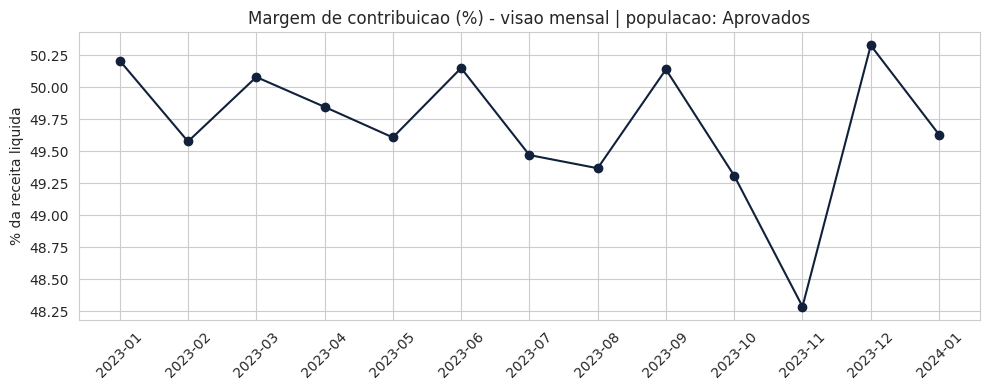

In [135]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

# Margem mensal (visão geral) - usando a populacao financeira oficial (Secao 1.1)
margem_mes = vendas_base_financeira.groupby('mes').agg(receita=('receita_liquida','sum'), pedidos=('order_id','count'),
                                        margem_pct=('margem_pct','mean'), desconto_pct=('desconto_pct','mean'),
                                        devolucao=('devolvido', lambda x: (x==True).mean()))
contexto_tabela('Margem por mes')
display(margem_mes.round(3))

fig, ax = plt.subplots(figsize=(10,4))
ax.plot(margem_mes.index, margem_mes['margem_pct']*100, marker='o', color='#12213B')
ax.set_title('Margem de contribuicao (%) - visao mensal | populacao: Aprovados'); ax.set_ylabel('% da receita liquida')
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

[Margem por categoria] Periodo: 2023-01-01 a 2024-01-26 | Populacao: vendas_base_financeira (status_pagamento == 'Aprovado', N=24454) | Unidade: R$ correntes | Devolucao: incluida na receita principal (corte de exposicao mostrado a parte, nao subtraido)


,receita,margem_total,pedidos,margem_pct_media_simples,margem_pct_ponderada
categoria,,,,,
Lifestyle,3425401.45,1854607.71,4964,0.496,0.541
Beleza,4971525.77,2700640.20,7367,0.493,0.543
Moda,5889322.89,3205720.95,8541,0.499,0.544
Acessórios,2382706.38,1297458.69,3582,0.495,0.545



=== Margem por canal (decomposta) ===
[Margem por canal] Periodo: 2023-01-01 a 2024-01-26 | Populacao: vendas_base_financeira (status_pagamento == 'Aprovado', N=24454) | Unidade: R$ correntes | Devolucao: incluida na receita principal (corte de exposicao mostrado a parte, nao subtraido)


,receita,margem_total,pedidos,ticket,margem_pct_media_simples,desconto_pct,custo_produto_pct,custo_frete_pct,margem_pct_ponderada,custo_frete_pct_ponderado
canal,,,,,,,,,,
Marketplace,3527694.64,1816773.02,5315,663.7243,0.4599,0.0799,0.3993,0.0866,0.5150,0.0490
Google Ads,3226402.62,1769101.86,4852,664.9634,0.5039,0.0843,0.4003,0.0428,0.5483,0.0098
Instagram Ads,2891577.19,1587840.94,4385,659.4247,0.5019,0.0809,0.4009,0.0453,0.5491,0.0101
Orgânico,1897091.66,1045512.45,2864,662.3923,0.5032,0.0777,0.4000,0.0480,0.5511,0.0111
TikTok Ads,1663325.55,917972.18,2568,647.7124,0.5039,0.0807,0.3977,0.0475,0.5519,0.0111
Influenciador,1809237.55,1002647.15,2006,901.9130,0.5235,0.0845,0.4012,0.0236,0.5542,0.0042
Email Marketing,1653627.28,918579.95,2464,671.1150,0.5104,0.0716,0.3993,0.0451,0.5555,0.0101


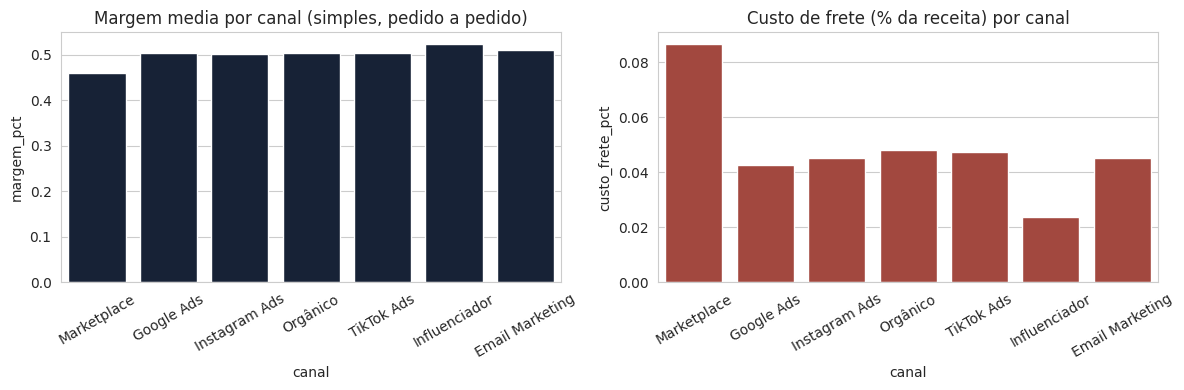

In [136]:
# Margem por categoria - media simples E media ponderada lado a lado (ver por que isso importa na proxima celula)
cat_margem = vendas_base_financeira.groupby('categoria').agg(
    receita=('receita_liquida','sum'), margem_total=('margem_contribuicao','sum'),
    pedidos=('order_id','count'), margem_pct_media_simples=('margem_pct','mean'))
cat_margem['margem_pct_ponderada'] = cat_margem['margem_total'] / cat_margem['receita']
contexto_tabela('Margem por categoria')
display(cat_margem.round(3).sort_values('margem_pct_ponderada'))

# Margem por canal - com decomposicao de custo
print("\n=== Margem por canal (decomposta) ===")
canal_margem = vendas_base_financeira.groupby('canal').agg(
    receita=('receita_liquida','sum'), margem_total=('margem_contribuicao','sum'),
    pedidos=('order_id','count'), ticket=('receita_liquida','mean'),
    margem_pct_media_simples=('margem_pct','mean'), desconto_pct=('desconto_pct','mean'),
    custo_produto_pct=('custo_produto', lambda x: (x/vendas_base_financeira.loc[x.index,'receita_bruta']).mean()),
    custo_frete_pct=('custo_frete_pct','mean'),
)
canal_margem['margem_pct_ponderada'] = canal_margem['margem_total'] / canal_margem['receita']

# (mentoria): custo_frete_pct acima e' media simples de uma razao por pedido - mesmo problema
# de ponderacao ja corrigido para margem. Denominador explicito para o business case:
# custo_frete_pct_ponderado = soma(custo_frete) / soma(receita_liquida), no recorte Aprovados.
frete_soma = vendas_base_financeira.groupby('canal')['custo_frete'].sum()
canal_margem['custo_frete_pct_ponderado'] = frete_soma / canal_margem['receita']

canal_margem = canal_margem.round(4).sort_values('margem_pct_ponderada')
contexto_tabela('Margem por canal')
display(canal_margem)

fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.barplot(data=vendas_base_financeira, x='canal', y='margem_pct', ax=axes[0], errorbar=None, order=canal_margem.index, color='#12213B')
axes[0].set_title('Margem media por canal (simples, pedido a pedido)'); axes[0].tick_params(axis='x', rotation=30)
sns.barplot(data=vendas_base_financeira, x='canal', y='custo_frete_pct', ax=axes[1], errorbar=None, order=canal_margem.index, color='#B23A2E')
axes[1].set_title('Custo de frete (% da receita) por canal'); axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

**Revisão de método após mentoria — por que existem duas colunas de margem acima:** a `margem_pct_media_simples` (`.mean()` pedido a pedido, usada na primeira versão desta AED) é distorcida por ~500 pedidos com margem negativa — o mínimo da base chega a **-169%** num único pedido. Isso puxa a média simples para baixo de forma desproporcional. A forma correta de comparar rentabilidade agregada entre canais é a **`margem_pct_ponderada`** (soma de `margem_contribuicao` dividida pela soma de `receita_liquida`), que pondera cada pedido pelo seu peso real na receita. Repare que a distância entre canais praticamente não muda de ordem, mas o **tamanho do gap muda** — é essa coluna que usamos daqui em diante para dimensionar qualquer oportunidade em R$. Todas as tabelas acima já usam vendas_base_financeira (só status_pagamento == 'Aprovado'), definida na Seção 1.1 — pedidos Cancelados e Aguardando não entram em nenhuma conta de margem.

In [137]:
# Checagem de mentoria: a margem_contribuicao ja desconta o efeito de uma devolucao?
# Compara a margem PONDERADA entre pedidos devolvidos e nao devolvidos - dentro de Aprovados.
dev_margem = vendas_base_financeira.groupby('devolvido').agg(
    pedidos=('order_id','count'), receita=('receita_liquida','sum'), margem_total=('margem_contribuicao','sum'))
dev_margem['margem_pct_ponderada'] = dev_margem['margem_total'] / dev_margem['receita']
contexto_tabela('Margem ponderada - devolvidos vs. nao devolvidos (dentro de Aprovados)')
display(dev_margem.round(3))
print("\n-> As margens sao praticamente identicas: margem_contribuicao NAO desconta nada quando devolvido=True.")
print("   A devolucao e' um driver de erosao separado e ainda nao contabilizado em nenhum numero acima.")
print("   NOTA: devolvido NAO e' subtraido da receita principal - e' um corte analitico dentro de Aprovados,")
print("   nao uma reversao de status_pagamento (ver Secao 1.1).")

# Devolucao: separar o que os dados MOSTRAM (exposicao observada) do que exigiria
# uma premissa extra (cenario de perda). Nao existe no dataset nenhum campo de reembolso,
# estorno, retorno ao estoque, revenda ou custo de logistica reversa - entao NAO chamamos
# isso de "perda" nem de "piso conservador" (um piso pressupoe que sabemos o chao; nao sabemos).
n_meses = vendas_base_financeira['mes'].nunique()

# --- Observado (fato, sem premissa) ---
margem_contabil_devolvidos_periodo = vendas_base_financeira.loc[
    vendas_base_financeira['devolvido'] == True, 'margem_contribuicao'].sum()
pct_devolvidos_aprovados = (vendas_base_financeira['devolvido'] == True).mean()

# Sensibilidade pedida: mesma taxa, mas contra TODOS os registros (nao so' Aprovados) -
# mostra se a leitura muda de tamanho ao trocar a populacao-base (mesmo espirito da Sec. 1.1).
pct_devolvidos_todos_registros = (vendas['devolvido'] == True).mean()

print("=== Devolucao - o que os dados MOSTRAM (observado, sem premissa) ===")
print(f"% de pedidos devolvidos - populacao oficial (Aprovados): {pct_devolvidos_aprovados*100:.2f}%")
print(f"% de pedidos devolvidos - sensibilidade (todos os registros, incl. Cancelado/Aguardando): {pct_devolvidos_todos_registros*100:.2f}%")
print(f"Margem contabil somada nos pedidos devolvidos (dentro de Aprovados, periodo observado): R$ {margem_contabil_devolvidos_periodo:,.0f}")
print("-> Isto e' um FATO: a formula de margem_contribuicao nao aplica nenhum ajuste quando devolvido=True.")
print("   Isto NAO e' o mesmo que dizer que essa margem foi efetivamente perdida.")

# --- Cenario (premissa explicita, rotulado como tal) ---
cenario_perda_bruta_anual_rs = margem_contabil_devolvidos_periodo / n_meses * 12

print("\n=== Cenario de perda bruta - SOB A HIPOTESE EXTREMA de que toda essa margem foi destruida ===")
print(f"Cenario de perda bruta anualizado: R$ {cenario_perda_bruta_anual_rs:,.0f} / ano")
print("Premissa por tras deste numero: nenhum produto devolvido foi recuperado/revendido, e o reembolso")
print("equivale a 100% da margem contabil do pedido. Isto e' o TETO do cenario, nao uma estimativa central.")

# --- Dado necessario para fechar a ponte financeira (o que falta para virar numero de verdade) ---
print("\n=== Ponte financeira que falta para transformar isto em impacto economico real ===")
print("pedido marcado como devolvido -> devolucao de fato concluida -> reembolso emitido ->")
print("custo de logistica reversa/reembalagem -> produto recuperado (revenda) ou perdido (baixa).")
print("Nenhuma dessas etapas existe como coluna neste dataset - ver kpis.json, campo 'dados_necessarios'.")

[Margem ponderada - devolvidos vs. nao devolvidos (dentro de Aprovados)] Periodo: 2023-01-01 a 2024-01-26 | Populacao: vendas_base_financeira (status_pagamento == 'Aprovado', N=24454) | Unidade: R$ correntes | Devolucao: incluida na receita principal (corte de exposicao mostrado a parte, nao subtraido)


,pedidos,receita,margem_total,margem_pct_ponderada
devolvido,,,,
False,20815,14168520.03,7706720.46,0.544
True,3639,2500436.46,1351707.09,0.541



-> As margens sao praticamente identicas: margem_contribuicao NAO desconta nada quando devolvido=True.
   A devolucao e' um driver de erosao separado e ainda nao contabilizado em nenhum numero acima.
   NOTA: devolvido NAO e' subtraido da receita principal - e' um corte analitico dentro de Aprovados,
   nao uma reversao de status_pagamento (ver Secao 1.1).
=== Devolucao - o que os dados MOSTRAM (observado, sem premissa) ===
% de pedidos devolvidos - populacao oficial (Aprovados): 14.88%
% de pedidos devolvidos - sensibilidade (todos os registros, incl. Cancelado/Aguardando): 14.87%
Margem contabil somada nos pedidos devolvidos (dentro de Aprovados, periodo observado): R$ 1,351,707
-> Isto e' um FATO: a formula de margem_contribuicao nao aplica nenhum ajuste quando devolvido=True.
   Isto NAO e' o mesmo que dizer que essa margem foi efetivamente perdida.

=== Cenario de perda bruta - SOB A HIPOTESE EXTREMA de que toda essa margem foi destruida ===
Cenario de perda bruta anualizado: R$ 

**Insight preliminar:** a margem mensal geral é estável (por volta de 50%), sem colapso ao longo do tempo, e a diferença entre categorias é pequena (49,3% a 49,9%). O sinal forte aparece **no corte por canal**: o **Marketplace** tem margem média de **~46,0%**, cerca de **4,6 p.p. abaixo** dos demais canais (~50,2%-52,5%), mesmo com custo de produto equivalente. A causa aparece na decomposição: o **custo de frete do Marketplace consome ~8,7% da receita**, quase o dobro dos outros canais (2,4%-4,8%) — plausivelmente taxas/logística da própria plataforma de marketplace. Como o Marketplace também é o **2º maior canal em receita e o de maior volume de pedidos**, essa perda de margem por pedido tem peso relevante no resultado total.

**Achado adicional, motivado pela mentoria:** a devolução (dentro de Aprovados) **não está descontada em `margem_contribuicao`** — é um segundo driver de erosão, totalmente separado do canal, que a primeira versão desta AED não tinha quantificado.

**Prompt utilizado:**

> Tarefa: recalcule o gap de margem do Marketplace usando margem PONDERADA (não a média simples), sobre a população vendas_base_financeira (só Aprovado). Substitua o teste t por um tamanho de efeito (Cohen's d) — com dezenas de milhares de linhas, qualquer diferença dá p muito baixo, então o p-valor sozinho não é uma evidência forte o suficiente; o Cohen's d mostra se a diferença é grande na prática, não só "estatisticamente real". Refaça o dimensionamento da oportunidade com a margem ponderada.
> Restrição: deixar a memória de cálculo explícita, e não apresentar nenhum número calculado sobre a população antiga (todos os registros válidos, sem filtrar Aprovado).

In [138]:
import numpy as np

# Cohen's d no lugar do teste t: mede o TAMANHO do efeito, nao so se ele e' "estatisticamente diferente de zero".
a = vendas_base_financeira[vendas_base_financeira['canal'] == 'Marketplace']['margem_pct']
b = vendas_base_financeira[vendas_base_financeira['canal'] != 'Marketplace']['margem_pct']
pooled_std = np.sqrt(((len(a)-1)*a.std()**2 + (len(b)-1)*b.std()**2) / (len(a)+len(b)-2))
cohend = (b.mean() - a.mean()) / pooled_std
print(f"Cohen's d (Marketplace vs. demais canais, dentro de Aprovados): {cohend:.2f}")
print("Referencia: ~0.2 = efeito pequeno | ~0.5 = medio | ~0.8+ = grande")
print("-> efeito pequeno-para-medio: real, mas modesto por pedido individual;")
print("   o que da peso financeiro e' o VOLUME do canal, nao a diferenca por pedido isoladamente.")

# Dimensionamento correto: Base Afetada x Alavanca, usando margem PONDERADA sobre vendas_base_financeira
receita_marketplace = canal_margem.loc['Marketplace', 'receita']
margem_pond_marketplace = canal_margem.loc['Marketplace', 'margem_pct_ponderada']
margem_pond_demais = (canal_margem.loc[canal_margem.index != 'Marketplace', 'margem_total'].sum()
                       / canal_margem.loc[canal_margem.index != 'Marketplace', 'receita'].sum())
gap_pp = margem_pond_demais - margem_pond_marketplace

oportunidade_periodo = receita_marketplace * gap_pp
oportunidade_anual = oportunidade_periodo / n_meses * 12

print(f"\n=== Memoria de calculo - Oportunidade de margem (Marketplace), populacao = Aprovados ===")
print(f"Margem ponderada Marketplace: {margem_pond_marketplace*100:.2f}%")
print(f"Margem ponderada demais canais (agregado): {margem_pond_demais*100:.2f}%")
print(f"Gap: {gap_pp*100:.2f} p.p.")
print(f"Receita liquida do Marketplace no periodo observado ({n_meses} meses, so Aprovados): R$ {receita_marketplace:,.0f}")
print(f"Oportunidade no periodo observado: R$ {oportunidade_periodo:,.0f}")
print(f"Oportunidade anualizada: R$ {oportunidade_anual:,.0f} / ano")

Cohen's d (Marketplace vs. demais canais, dentro de Aprovados): 0.28
Referencia: ~0.2 = efeito pequeno | ~0.5 = medio | ~0.8+ = grande
-> efeito pequeno-para-medio: real, mas modesto por pedido individual;
   o que da peso financeiro e' o VOLUME do canal, nao a diferenca por pedido isoladamente.

=== Memoria de calculo - Oportunidade de margem (Marketplace), populacao = Aprovados ===
Margem ponderada Marketplace: 51.50%
Margem ponderada demais canais (agregado): 55.11%
Gap: 3.61 p.p.
Receita liquida do Marketplace no periodo observado (13 meses, so Aprovados): R$ 3,527,695
Oportunidade no periodo observado: R$ 127,217
Oportunidade anualizada: R$ 117,431 / ano


**Insights da Hipótese 1 — Margem (confirmada, com número corrigido)**

- Usando a margem **ponderada** (não a média simples pedido a pedido), o gap real do Marketplace é **3,61 p.p.**, e a oportunidade anualizada corrigida é **≈ R\$ 117,4 mil/ano**
- O Cohen's d (0,28) mostra que o efeito é **real, mas pequeno-para-médio por pedido**; o que dá relevância financeira é o Marketplace ser o canal de maior volume — não a magnitude da diferença por pedido isoladamente. Preferimos essa leitura a um p-valor de teste t, que com quase 28 mil linhas seria estatisticamente "significativo" mesmo para diferenças irrelevantes na prática.
- **Causa raiz identificada:** custo de frete/logística do Marketplace, não desconto nem mix de categoria.
- **Achado da devolução:** os dados mostram um fato (14,9% dos pedidos são devolvidos; a margem contábil desses pedidos é praticamente igual à dos não devolvidos — a fórmula não aplica nenhum desconto de devolução). O que os dados não mostram é se essa margem foi de fato perdida: não há coluna de reembolso, estorno, retorno ao estoque, revenda ou custo de logística reversa. Por isso reportamos dois números com rótulos diferentes: a exposição observada (fato) e um cenário de perda bruta sob hipótese extrema (toda a margem contábil tratada como destruída) — nunca uma "economia garantida" como a de frete ou WISMO.
- **Ação recomendada:** (1) renegociar frete/comissão do Marketplace; (2) levar ao CFO a pergunta "o que acontece financeiramente com um pedido devolvido?" antes de comprometer o número de devolução como meta — hoje a base não informa reembolso, estorno, retorno ao estoque, revenda ou custo de logística reversa.


### Separando diferença observada de economia capturável (frete Marketplace)

O gap de margem do Marketplace (Seção anterior) foi decomposto até o custo de frete — mas isso ainda é uma **camada descritiva**, não uma prova de que o custo é evitável. `custo_frete` é um custo **registrado** na empresa; a base não diz se é repasse ao cliente, subsídio, comissão contratual da plataforma ou custo sintético do dataset.

| Camada | O que já comprovamos | O que ainda precisa validar |
|---|---|---|
| **Descritiva** | Marketplace tem menor margem e maior custo de frete registrado (ponderado, denominador explícito abaixo). | O recorte financeiro oficial e o denominador usado (feito nesta seção). |
| **Mecanismo** | Frete está associado ao gap na decomposição contábil. | Se é contrato obrigatório, repasse ao cliente, elegibilidade por SKU/ticket, efeito sobre conversão. |
| **Valor** | Há um **gap anualizado** sob o cenário teórico de equiparar a margem do Marketplace à dos demais canais. | Qual fração desse gap é **realmente capturável**, e a que custo de implementação. |
| **Ação** | Renegociar/revisar frete é uma hipótese coerente. | Qual intervenção testar, e qual guardrail protege conversão/margem durante o teste. |


In [139]:

# custo de frete com denominador explicito (soma/soma, nao media simples de razao por pedido)
print(f"Custo de frete ponderado - Marketplace: {kpis_financeiros['frete_pct_ponderado_marketplace']:.2f}% da receita")
print(f"Custo de frete ponderado - demais canais (agregado): {kpis_financeiros['frete_pct_ponderado_demais_canais']:.2f}% da receita")
print(f"Gap de frete: {kpis_financeiros['gap_frete_pp']:.2f} p.p.")
print(f"\nGap OBSERVADO anualizado (100% do gap de frete, cenario teorico - NAO e economia capturavel): "
      f"R$ {kpis_financeiros['oportunidade_frete_gap_observado_anual_rs']:,.0f}")

print("\n=== Cenarios de captura (fracao do gap tratada como potencialmente evitavel) ===")
for taxa, chave in [(25, 'oportunidade_frete_cenario_25pct_rs'), (50, 'oportunidade_frete_cenario_50pct_rs'), (75, 'oportunidade_frete_cenario_75pct_rs')]:
    print(f"  Captura de {taxa}%: R$ {kpis_financeiros[chave]:,.0f}/ano")
print("\n(Nenhum destes cenarios inclui custo de implementacao nem efeito sobre conversao - ver checklist abaixo.)")


Custo de frete ponderado - Marketplace: 4.90% da receita
Custo de frete ponderado - demais canais (agregado): 0.95% da receita
Gap de frete: 3.95 p.p.

Gap OBSERVADO anualizado (100% do gap de frete, cenario teorico - NAO e economia capturavel): R$ 128,574

=== Cenarios de captura (fracao do gap tratada como potencialmente evitavel) ===
  Captura de 25%: R$ 32,144/ano
  Captura de 50%: R$ 64,287/ano
  Captura de 75%: R$ 96,431/ano

(Nenhum destes cenarios inclui custo de implementacao nem efeito sobre conversao - ver checklist abaixo.)



**Resposta à pergunta de mentoria — "o valor representa custo registrado, economia possível ou economia garantida?"**

É **custo registrado com um gap observado** — não é economia possível nem garantida ainda. Para mover de categoria:

- **Custo registrado → economia possível:** confirmar com o financeiro/jurídico o mecanismo do `custo_frete` no Marketplace (contrato, repasse, comissão, subsídio) e testar se ele é de fato negociável.
- **Economia possível → economia garantida:** rodar um experimento controlado (ex.: nova política de frete só para uma fração de SKUs/pedidos do Marketplace) e medir o efeito real em margem **e** em conversão/volume antes de comprometer qualquer número no business case.

**Validação operacional necessária antes de qualquer meta de R\$:**
- Contrato vigente com a plataforma de marketplace (cláusulas de frete/comissão).
- Política de subsídio de frete (se existir) e quem a paga hoje.
- Elegibilidade por faixa de ticket/SKU (nem todo pedido pode ter a mesma alavanca).
- Experimento controlado (A/B ou piloto) medindo margem *e* conversão, não só custo.

**Decisão de análise:** a partir daqui, `oportunidade_marketplace_anual_rs` e o gap de frete são tratados como **cenário observado**, não como linha "garantida" na tabela de priorização (ver Seção 8.1, corrigida abaixo).


---
## 4. Hipótese 2 — Marketing: nem todo canal gera crescimento igualmente valioso

**Objetivo:** classificar os canais de aquisição por qualidade (ROAS, CAC, margem, ticket) e não apenas por volume, cruzando `marketing.csv` com o que já vimos em `vendas.csv`.

**Prompt utilizado:**

> Papel: Analista de performance de marketing.
> Contexto: marketing.csv traz investimento, ROAS e CAC por campanha e canal; já sabemos por vendas.csv a margem e o ticket médio por canal.
> Tarefa: agregue ROAS médio, CAC médio e investimento total por canal em marketing.csv. Junte com a margem e o ticket médio por canal calculados em vendas.csv. Monte um raciocínio de "qualidade do canal" (não apenas volume) e aponte quais canais merecem mais investimento e quais merecem revisão.
> Formato: tabela cruzada ordenada por ROAS + gráfico de dispersão ROAS x Margem, com o tamanho do ponto representando o investimento.
> Restrição: como os períodos de marketing.csv e vendas.csv não coincidem totalmente (ver alerta da Seção 1), a leitura deve ser em termos relativos (ranking entre canais), não de retorno absoluto reconciliado.

In [140]:
mkt_canal = marketing.groupby('canal').agg(
    investimento=('investimento_reais','sum'), receita_gerada=('receita_gerada','sum'),
    roas_medio=('roas','mean'), cac_medio=('cac','mean'), conversoes=('conversoes','sum'),
    campanhas=('campanha_id','count'))

margem_canal = vendas_base_financeira.groupby('canal').agg(margem_pct=('margem_pct','mean'), ticket=('receita_liquida','mean'),
                                            pedidos=('order_id','count'))

qualidade_canal = mkt_canal.join(margem_canal).round(3)
qualidade_canal = qualidade_canal.sort_values('roas_medio', ascending=False)
contexto_tabela('Qualidade de canal (ROAS/CAC de marketing.csv x margem/ticket de vendas_base_financeira)')
display(qualidade_canal)

[Qualidade de canal (ROAS/CAC de marketing.csv x margem/ticket de vendas_base_financeira)] Periodo: 2023-01-01 a 2024-01-26 | Populacao: vendas_base_financeira (status_pagamento == 'Aprovado', N=24454) | Unidade: R$ correntes | Devolucao: incluida na receita principal (corte de exposicao mostrado a parte, nao subtraido)


,investimento,receita_gerada,roas_medio,cac_medio,conversoes,campanhas,margem_pct,ticket,pedidos
canal,,,,,,,,,
Influenciador,28061599.02,2.175780e+08,7.692,4.173,15940484,465,0.523,901.913,2006
TikTok Ads,29770101.07,1.390634e+08,4.667,3.955,17009948,488,0.504,647.712,2568
Instagram Ads,30165772.33,1.359386e+08,4.426,4.717,15360484,518,0.502,659.425,4385
Google Ads,30224839.25,1.065574e+08,3.514,4.270,16118323,509,0.504,664.963,4852
Marketplace,32682629.69,9.879591e+07,3.005,4.386,17894187,540,0.460,663.724,5315
Email Marketing,29700531.98,9.104621e+07,2.998,4.292,16563197,485,0.510,671.115,2464
Orgânico,29808867.75,8.964926e+07,2.993,4.656,16401820,495,0.503,662.392,2864


**Prompt utilizado adicionado após a mentoria:**

> Tarefa: antes de usar ROAS/CAC ao lado de qualquer numero de vendas.csv, verifique se as duas bases realmente reconciliam. Filtre marketing.csv para campanhas com data_inicio dentro da janela coberta por vendas.csv (jan/2023 a jan/2024). Some investimento_reais e receita_gerada nessa janela e compare com a receita_liquida real de vendas.csv no mesmo periodo. Verifique tambem se cada canal usa um modelo de atribuicao (atribuicao) diferente, o que enviesaria o ranking de ROAS entre canais.
> Restrição: se a reconciliação falhar, deixe isso explícito e não combine os dois números numa mesma conta de R$.

In [141]:
# Checagem de mentoria: marketing.csv e vendas_base_financeira foram desenhados para conversar entre si?
janela_ini, janela_fim = vendas_base_financeira['data_pedido'].min(), vendas_base_financeira['data_pedido'].max()
mkt_janela = marketing[(marketing['data_inicio'] >= janela_ini) & (marketing['data_inicio'] <= janela_fim)]

investimento_janela = mkt_janela['investimento_reais'].sum()
receita_atribuida_janela = mkt_janela['receita_gerada'].sum()
receita_real = vendas_base_financeira['receita_liquida'].sum()

print(f"Investimento total em marketing na janela de vendas_base_financeira: R$ {investimento_janela:,.0f}")
print(f"Receita 'gerada' atribuida pelas campanhas na mesma janela: R$ {receita_atribuida_janela:,.0f}")
print(f"Receita liquida REAL (Aprovados) no periodo: R$ {receita_real:,.0f}")
print(f"Investimento / Receita real: {investimento_janela/receita_real*100:.0f}%")
print(f"Receita atribuida / Receita real: {receita_atribuida_janela/receita_real:.1f}x")

print("\n=== canal x modelo de atribuicao (distribuicao dentro de cada canal) ===")
display(pd.crosstab(marketing['canal'], marketing['atribuicao'], normalize='index').round(2))

Investimento total em marketing na janela de vendas_base_financeira: R$ 75,280,098
Receita 'gerada' atribuida pelas campanhas na mesma janela: R$ 315,414,157
Receita liquida REAL (Aprovados) no periodo: R$ 16,668,956
Investimento / Receita real: 452%
Receita atribuida / Receita real: 18.9x

=== canal x modelo de atribuicao (distribuicao dentro de cada canal) ===


atribuicao,First Click,Last Click,Linear
canal,,,
Email Marketing,0.33,0.34,0.33
Google Ads,0.31,0.35,0.35
Influenciador,0.34,0.33,0.33
Instagram Ads,0.35,0.33,0.32
Marketplace,0.31,0.36,0.33
Orgânico,0.33,0.32,0.36
TikTok Ads,0.30,0.35,0.35


**Resultado da checagem — bases não reconciliam:** o investimento em marketing na mesma janela de `vendas.csv` equivale a **452% da receita real**, e a receita atribuída pelas campanhas é **18,9x maior** que a receita líquida real. As duas bases foram geradas em escalas independentes — **não é possível combinar ROAS/CAC de `marketing.csv` com nenhum valor de `vendas.csv` numa mesma conta de R\$.** Sobre atribuição: checando de fato, o modelo (`Linear`/`First Click`/`Last Click`) se distribui de forma quase uniforme (~33% cada) **dentro de cada canal** — ou seja, não é verdade que um canal específico esteja sendo favorecido por um modelo diferente; esse ponto de atenção específico não se confirma, embora o problema de escala acima permaneça de pé.

**Decisão de análise:** o gráfico e o ranking abaixo continuam válidos como **comparação relativa entre canais** (qual tem melhor ROAS/margem/ticket que o outro) — é só a combinação em R\$ absolutos que fica proibida.

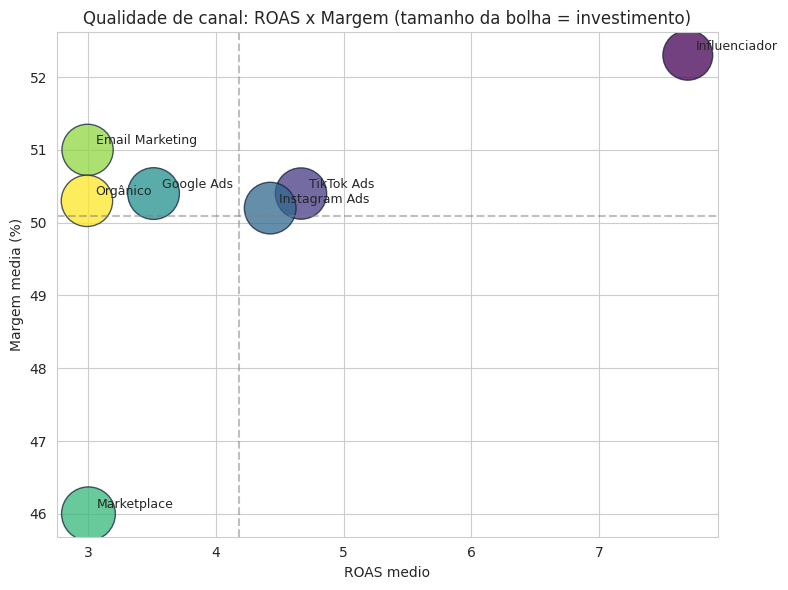

In [142]:
fig, ax = plt.subplots(figsize=(8,6))
sizes = (qualidade_canal['investimento'] / qualidade_canal['investimento'].max()) * 1500
sc = ax.scatter(qualidade_canal['roas_medio'], qualidade_canal['margem_pct']*100, s=sizes,
                 c=range(len(qualidade_canal)), cmap='viridis', alpha=0.75, edgecolors='#12213B')
for canal, row in qualidade_canal.iterrows():
    ax.annotate(canal, (row['roas_medio'], row['margem_pct']*100), textcoords="offset points", xytext=(6,4), fontsize=9)
ax.axhline(qualidade_canal['margem_pct'].mean()*100, color='grey', linestyle='--', alpha=0.5)
ax.axvline(qualidade_canal['roas_medio'].mean(), color='grey', linestyle='--', alpha=0.5)
ax.set_xlabel('ROAS medio'); ax.set_ylabel('Margem media (%)')
ax.set_title('Qualidade de canal: ROAS x Margem (tamanho da bolha = investimento)')
plt.tight_layout(); plt.show()

**Insights da Hipótese 2 — Marketing (confirmada apenas como ranking direcional, sem R$)**

- **Influenciador** se destaca em todas as métricas de qualidade: **maior ROAS (7,7)**, **maior margem (52,3%)** e **maior ticket médio (R\$ 902)** — é o canal que combina volume com rentabilidade, *relativamente* aos demais.
- **Marketplace** confirma o problema identificado na Seção 3: **ROAS mediano (3,0)** e a **pior margem** entre todos os canais — é o clássico "canal que traz volume, mas com qualidade de crescimento inferior".
- **Correção após mentoria:** a diferença de ROAS entre canais **não é explicada por modelo de atribuição diferente por canal** (todos usam os 3 modelos quase igualmente). O que invalida qualquer leitura financeira é outro problema, mais grave: `marketing.csv` e `vendas.csv` não reconciliam em escala nenhuma (452% / 18,9x), então **nenhum R\$ de "receita gerada por marketing" pode aparecer no business case**.
- **Ação recomendada:** usar o ranking de ROAS/margem apenas como **sinal direcional** para prioridade de investimento (ex.: Influenciador > Marketplace), sem anexar um valor de retorno em R\$ — e pedir ao time de marketing a base de investimento real por canal na mesma janela de vendas, para permitir uma conta de verdade no próximo ciclo.

---
## 5. Hipótese 3 — Operações: falhas de estoque destroem valor?

**Objetivo:** identificar se ruptura/estoque crítico está concentrado em algum recorte (categoria, fornecedor) e dimensionar o risco de receita não capturada.

**Prompt utilizado:**

> Papel: Analista de supply chain / operações de e-commerce.
> Contexto: estoque.csv tem status_disponibilidade (Em Estoque, Estoque Crítico, Ruptura, Descontinuado) por SKU, categoria, fornecedor, lead time e shelf_life_dias.
> Tarefa: calcule a distribuição de status de disponibilidade por categoria e por fornecedor. Se algum recorte concentrar desproporcionalmente rupturas/estoque crítico, investigue a causa provável (lead time, shelf life). Depois, cruzando com vendas.csv por sku_id, estime a receita mensal média por SKU saudável no recorte afetado, para dimensionar a receita potencialmente perdida pelos SKUs em ruptura/crítico.
> Formato: tabelas cruzadas + estimativa de perda com premissa de duração de ruptura explícita (cenários).

In [143]:
# @title
print("=== Distribuicao de status por categoria (% de SKUs) ===")
display(estoque.groupby('categoria')['status_disponibilidade'].value_counts(normalize=True).unstack().round(3))

print("\n=== Shelf life por categoria (dias) ===")
display(estoque.groupby('categoria')['shelf_life_dias'].describe()[['mean','std','min','max']].round(1))

# P1 - antes de atribuir a causa a shelf life, controlar por outros fatores que tambem
# poderiam explicar a concentracao de ruptura em Beleza.
print("\n=== Outros fatores por categoria (checagem de confundidores, antes de atribuir causa) ===")
display(estoque.groupby('categoria').agg(
    lead_time_medio_dias=('lead_time_reposicao', 'mean'),
    ponto_pedido_medio=('ponto_pedido', 'mean'),
    n_fornecedores=('fornecedor_id', 'nunique'),
).round(1))
print("-> lead time (~26-28 dias), ponto de pedido (~80-82) e numero de fornecedores (100) sao")
print("   praticamente IDENTICOS entre categorias - nenhum deles explica a concentracao em Beleza.")
print("   Isso reforca (nao prova) shelf life como diferenciador, por eliminacao dos concorrentes obvios.")

=== Distribuicao de status por categoria (% de SKUs) ===


status_disponibilidade,Descontinuado,Em Estoque,Estoque Crítico,Ruptura
categoria,,,,
Acessórios,0.048,0.785,0.166,0.001
Beleza,0.044,0.739,0.153,0.063
Lifestyle,0.038,0.778,0.183,0.001
Moda,0.038,0.869,0.093,0.001



=== Shelf life por categoria (dias) ===


,mean,std,min,max
categoria,,,,
Acessórios,448.0,0.0,448.0,448.0
Beleza,449.1,160.1,180.0,730.0
Lifestyle,448.0,0.0,448.0,448.0
Moda,448.0,0.0,448.0,448.0



=== Outros fatores por categoria (checagem de confundidores, antes de atribuir causa) ===


,lead_time_medio_dias,ponto_pedido_medio,n_fornecedores
categoria,,,
Acessórios,27.6,80.9,100
Beleza,26.3,80.2,100
Lifestyle,26.7,80.9,100
Moda,27.5,81.9,100


-> lead time (~26-28 dias), ponto de pedido (~80-82) e numero de fornecedores (100) sao
   praticamente IDENTICOS entre categorias - nenhum deles explica a concentracao em Beleza.
   Isso reforca (nao prova) shelf life como diferenciador, por eliminacao dos concorrentes obvios.


In [144]:
# A categoria Beleza concentra quase toda a ruptura -> investigar shelf life variavel
beleza = estoque[estoque['categoria'] == 'Beleza'].copy()

# separar RUPTURA (venda ja bloqueada agora) de ESTOQUE CRITICO (risco, ainda ha estoque).
# Sao estados diferentes e nao representam a mesma perda - tratar como a mesma coisa superestima
# o que ja aconteceu e subestima a urgencia do que ainda pode acontecer.
n_ruptura_beleza = (beleza['status_disponibilidade'] == 'Ruptura').sum()
n_critico_beleza = (beleza['status_disponibilidade'] == 'Estoque Crítico').sum()
print(f"SKUs de Beleza: {len(beleza)}")
print(f"  - Ruptura (venda bloqueada AGORA): {n_ruptura_beleza}")
print(f"  - Estoque Critico (risco, ainda ha estoque): {n_critico_beleza}")
print(f"Ruptura em Beleza: {n_ruptura_beleza} de {(estoque['status_disponibilidade']=='Ruptura').sum()} rupturas totais na empresa")

# Receita media mensal por SKU (para SKUs de Beleza saudaveis) - usada como proxy de velocidade de venda
n_meses_vendas = vendas_base_financeira['mes'].nunique()
receita_sku_mes = vendas_base_financeira.groupby('sku_id')['receita_liquida'].sum() / n_meses_vendas
beleza['receita_media_mes'] = beleza['sku_id'].map(receita_sku_mes).fillna(0)
receita_media_sku_saudavel = beleza[beleza['status_disponibilidade']=='Em Estoque']['receita_media_mes'].mean()

print(f"\nReceita media mensal por SKU saudavel de Beleza: R$ {receita_media_sku_saudavel:.2f}")

# tabela por status pedida pela mentoria: SKU, receita historica, lead time, shelf life,
# fornecedor e ponto de pedido - para investigacao operacional direta, nao so' um numero agregado.
tabela_beleza_por_status = beleza[beleza['status_disponibilidade'].isin(['Ruptura', 'Estoque Crítico'])][[
    'sku_id', 'nome_produto', 'status_disponibilidade', 'receita_media_mes',
    'lead_time_reposicao', 'shelf_life_dias', 'fornecedor_id', 'ponto_pedido'
]].sort_values(['status_disponibilidade', 'receita_media_mes'], ascending=[True, False])

print("\n=== Tabela por status - Beleza em Ruptura/Estoque Critico (para investigacao operacional) ===")
display(tabela_beleza_por_status.head(15))
print(f"(tabela completa tem {len(tabela_beleza_por_status)} linhas - use para priorizar reposicao por SKU)")

# sizing como RECEITA POTENCIAL DE CENARIO, aplicado SOMENTE aos SKUs em ruptura EFETIVA
# (venda ja bloqueada). Estoque Critico fica de fora do R$ - e' risco futuro, nao perda ja ocorrida.
print("\n=== Cenarios de receita potencial (nao e perda comprovada nem margem capturada) ===")
print("Aplicado apenas aos SKUs em RUPTURA efetiva (nao a Estoque Critico, que ainda nao bloqueou venda):")
for meses_ruptura in [0.5, 1.0, 2.0]:
    receita_potencial = n_ruptura_beleza * receita_media_sku_saudavel * meses_ruptura
    print(f"  Assumindo {meses_ruptura} mes(es) de indisponibilidade media: R$ {receita_potencial:,.0f} de receita potencial")

# Cenario central (1 mes) e faixa, guardados em variaveis nomeadas - reaproveitados na
# priorizacao (Secao 8) e no kpis.json, em vez de digitar os numeros de novo.
receita_potencial_central_ruptura_beleza = n_ruptura_beleza * receita_media_sku_saudavel * 1.0
receita_potencial_min_ruptura_beleza = n_ruptura_beleza * receita_media_sku_saudavel * 0.5
receita_potencial_max_ruptura_beleza = n_ruptura_beleza * receita_media_sku_saudavel * 2.0

# Estoque Critico: reportado como RISCO (receita mensal exposta se virar ruptura), nunca somado
# ao cenario de receita potencial acima - sao coisas diferentes.
receita_mensal_em_risco_estoque_critico = n_critico_beleza * receita_media_sku_saudavel
print(f"\nEstoque Critico (risco, NAO somado ao cenario acima): {n_critico_beleza} SKUs, "
      f"R$ {receita_mensal_em_risco_estoque_critico:,.0f}/mes de receita exposta SE virarem ruptura.")

SKUs de Beleza: 1512
  - Ruptura (venda bloqueada AGORA): 96
  - Estoque Critico (risco, ainda ha estoque): 232
Ruptura em Beleza: 96 de 99 rupturas totais na empresa

Receita media mensal por SKU saudavel de Beleza: R$ 251.82

=== Tabela por status - Beleza em Ruptura/Estoque Critico (para investigacao operacional) ===


,sku_id,nome_produto,status_disponibilidade,receita_media_mes,lead_time_reposicao,shelf_life_dias,fornecedor_id,ponto_pedido
3824,SKU-03825,Condicionador Sport Nude,Estoque Crítico,1037.630000,14,577,FORN-078,39
3203,SKU-03204,Máscara de Cílios Artesanal Bege,Estoque Crítico,832.133077,14,423,FORN-089,114
782,SKU-00783,Creme Hidratante Básico Bege,Estoque Crítico,770.649231,15,340,FORN-036,66
916,SKU-00917,Esfoliante Edição Limitada Vermelho,Estoque Crítico,737.835385,12,438,FORN-049,100
227,SKU-00228,Esfoliante Clássico Nude,Estoque Crítico,692.812308,55,462,FORN-034,109
229,SKU-00230,Óleo Corporal Edição Limitada Rosa,Estoque Crítico,686.842308,60,591,FORN-050,113
4370,SKU-04371,Blush Delicado Rosa,Estoque Crítico,680.666154,47,325,FORN-074,81
2192,SKU-02193,Batom Premium Branco,Estoque Crítico,676.175385,56,295,FORN-034,78
4147,SKU-04148,Batom Edição Limitada Verde,Estoque Crítico,611.460769,56,643,FORN-018,141
4010,SKU-04011,Condicionador Clássico Prata,Estoque Crítico,608.752308,55,487,FORN-029,69


(tabela completa tem 328 linhas - use para priorizar reposicao por SKU)

=== Cenarios de receita potencial (nao e perda comprovada nem margem capturada) ===
Aplicado apenas aos SKUs em RUPTURA efetiva (nao a Estoque Critico, que ainda nao bloqueou venda):
  Assumindo 0.5 mes(es) de indisponibilidade media: R$ 12,087 de receita potencial
  Assumindo 1.0 mes(es) de indisponibilidade media: R$ 24,174 de receita potencial
  Assumindo 2.0 mes(es) de indisponibilidade media: R$ 48,349 de receita potencial

Estoque Critico (risco, NAO somado ao cenario acima): 232 SKUs, R$ 58,421/mes de receita exposta SE virarem ruptura.


**Insights da Hipótese 3 — Operações (achado observado + hipótese condicionada, não causa comprovada)**

- **Observado no snapshot (fato):** ruptura e estoque crítico estão concentrados na categoria Beleza — **96 de 99 rupturas efetivas da empresa (97%)** e **232 SKUs adicionais em estoque crítico** (risco, ainda não bloqueado) estão em Beleza.
- **Hipótese exploratória, não causa-raiz comprovada:** Beleza é a única categoria com `shelf_life_dias` variável (180 a 730 dias, vs. 448 dias fixo nas demais). Checamos os concorrentes óbvios — lead time de reposição, ponto de pedido e número de fornecedores são praticamente idênticos entre categorias — então nenhum deles explica a concentração. Isso *reforça* shelf life como diferenciador plausível, mas não é uma prova causal: estoque é uma fotografia (sem série temporal de disponibilidade, demanda não atendida ou backorder), então não dá pra confirmar causa-efeito com este dataset.
- **Ruptura ≠ Estoque Crítico — não são a mesma perda:** ruptura (96 SKUs) já bloqueia venda agora; estoque crítico (232 SKUs) ainda tem estoque, é risco de virar ruptura, não perda ocorrida. Tratar os dois juntos como "perda" infla o número e mistura fato com risco futuro.
- **Receita potencial de cenário (não é margem capturada nem perda comprovada):** aplicando só aos 96 SKUs em ruptura efetiva, entre **R\$ 12,1 mil e R\$ 48,3 mil** no período, a depender da duração assumida (0,5 a 2 meses) — é receita bruta potencial, não margem, e depende de uma premissa de duração que o dataset não confirma.
- **Estoque Crítico tratado como risco, não como R$:** os 232 SKUs em estoque crítico representam ~R\$ 58,4 mil/mês de receita exposta *se* virarem ruptura — reportado como sinal de urgência para reposição, não somado a nenhum cenário de perda.
- **Dado necessário para virar causa-raiz e perda comprovada:** série temporal de disponibilidade por SKU (`dias_sem_estoque`), duração real de cada ruptura, demanda não atendida (proxy de vendas perdidas), registro de backorder e substituição de produto.
- **Ação recomendada:** investigação operacional da categoria Beleza (não só "ajustar shelf life") — revisar ponto de pedido e lead time olhando SKU a SKU pela tabela acima, priorizando por receita histórica; tratar a lista de Estoque Crítico como fila de reposição preventiva antes que vire ruptura.

---
## 6. Hipótese 4 — Atendimento: causas-raiz recorrentes e potencial de automação

**Objetivo:** mapear quais temas de ticket mais se repetem, qual sua qualidade de resolução (CSAT) e estimar o ganho de produtividade/custo com automação da triagem.

**Prompt utilizado:**

> Papel: Analista de Customer Experience / Operações de atendimento.
> Contexto: atendimento.csv traz categoria_problema, canal_entrada, nota_csat, tempo_primeira_resposta_minutos e custo_operacional_ticket por ticket.
> Tarefa: identifique o tema de ticket mais frequente e sua nota de CSAT. Compare custo médio e tempo de resposta entre canais de entrada (ChatBot vs. humanos). Se o ChatBot tiver CSAT comparável aos canais humanos com custo muito menor, estime a economia de automatizar o tema mais frequente, assumindo diferentes taxas de automação possíveis (cenários).
> Formato: tabelas por tema e por canal + memória de cálculo da economia estimada.

In [145]:
print("=== Volume e CSAT por categoria de problema ===")
display(atendimento.groupby('categoria_problema').agg(
    tickets=('ticket_id','count'), csat_medio=('nota_csat','mean'),
    tempo_resposta_min=('tempo_primeira_resposta_minutos','mean'),
    custo_medio=('custo_operacional_ticket','mean')).round(2).sort_values('tickets', ascending=False))

print("\n=== Custo e tempo de resposta por canal de entrada ===")
display(atendimento.groupby('canal_entrada').agg(
    tickets=('ticket_id','count'), csat_medio=('nota_csat','mean'),
    tempo_resposta_min=('tempo_primeira_resposta_minutos','mean'),
    custo_medio=('custo_operacional_ticket','mean')).round(2).sort_values('custo_medio'))

# checar se canal_entrada realmente sinaliza quem RESOLVEU o ticket (nao so' onde entrou).
print("\n=== status_atendimento por canal de entrada (%) - canal prediz resolucao? ===")
display(pd.crosstab(atendimento['canal_entrada'], atendimento['status_atendimento'], normalize='index').round(3))
print("-> as distribuicoes sao praticamente IDENTICAS entre canais (~65% Resolvido, ~10% Escalado")
print("   para N2, em todos eles). Isso sugere que status_atendimento NAO captura se o bot resolveu")
print("   sem humano - e' um status de ciclo de vida do ticket, independente do canal de entrada.")

=== Volume e CSAT por categoria de problema ===


,tickets,csat_medio,tempo_resposta_min,custo_medio
categoria_problema,,,,
Onde está meu pedido?,10765,2.99,137.00,14.83
Defeito,6509,2.82,135.87,14.84
Troca de Tamanho,5360,2.99,131.22,14.80
Dúvida Técnica,5314,3.83,136.50,14.85
Pagamento não aprovado,4281,2.99,134.33,14.92
Elogio,3611,4.57,135.73,14.94



=== Custo e tempo de resposta por canal de entrada ===


,tickets,csat_medio,tempo_resposta_min,custo_medio
canal_entrada,,,,
ChatBot,7170,3.27,1.50,2.0
E-mail,8930,3.27,269.61,15.0
Telefone,4160,3.29,11.49,15.0
WhatsApp,12651,3.18,8.48,15.0
Reclame Aqui,2929,3.30,778.33,45.0



=== status_atendimento por canal de entrada (%) - canal prediz resolucao? ===


status_atendimento,Aberto,Em Análise,Escalado para N2,Resolvido
canal_entrada,,,,
ChatBot,0.097,0.148,0.102,0.653
E-mail,0.100,0.153,0.097,0.649
Reclame Aqui,0.101,0.144,0.099,0.657
Telefone,0.098,0.144,0.108,0.650
WhatsApp,0.103,0.146,0.099,0.651


-> as distribuicoes sao praticamente IDENTICAS entre canais (~65% Resolvido, ~10% Escalado
   para N2, em todos eles). Isso sugere que status_atendimento NAO captura se o bot resolveu
   sem humano - e' um status de ciclo de vida do ticket, independente do canal de entrada.


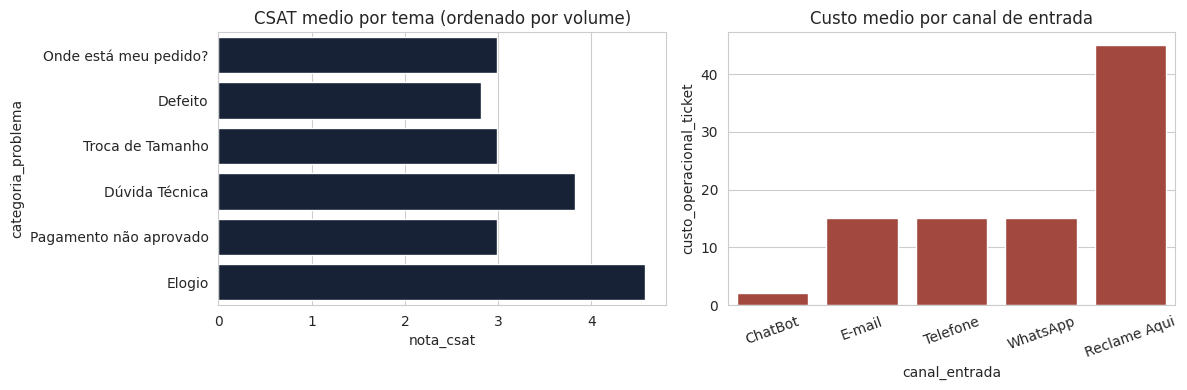

In [146]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
ordem_tema = atendimento['categoria_problema'].value_counts().index
sns.barplot(data=atendimento, y='categoria_problema', x='nota_csat', order=ordem_tema, ax=axes[0], color='#12213B', errorbar=None)
axes[0].set_title('CSAT medio por tema (ordenado por volume)')
sns.barplot(data=atendimento, x='canal_entrada', y='custo_operacional_ticket', ax=axes[1], errorbar=None,
            order=atendimento.groupby('canal_entrada')['custo_operacional_ticket'].mean().sort_values().index, color='#B23A2E')
axes[1].set_title('Custo medio por canal de entrada'); axes[1].tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()

In [147]:
# Tema mais frequente: "Onde esta meu pedido?" (WISMO) - candidato a automacao (rastreio de pedido)
wismo = atendimento[atendimento['categoria_problema'] == 'Onde está meu pedido?'].copy()
custo_medio_wismo = wismo['custo_operacional_ticket'].mean()
custo_medio_chatbot = atendimento[atendimento['canal_entrada']=='ChatBot']['custo_operacional_ticket'].mean()
csat_chatbot = atendimento[atendimento['canal_entrada']=='ChatBot']['nota_csat'].mean()
csat_geral = atendimento['nota_csat'].mean()

n_meses_atend = atendimento['data_abertura'].dt.to_period('M').nunique()
gap_custo = custo_medio_wismo - custo_medio_chatbot

print(f"Tickets 'Onde esta meu pedido?': {len(wismo)} ({len(wismo)/len(atendimento)*100:.1f}% do volume total)")
print(f"Custo medio desse tema: R$ {custo_medio_wismo:.2f} | Custo medio no canal ChatBot: R$ {custo_medio_chatbot:.2f}")
print(f"CSAT ChatBot: {csat_chatbot:.2f} | CSAT geral da base: {csat_geral:.2f}  (comparavel, nao ha perda de qualidade percebida)")
print(f"Periodo coberto por atendimento_1_.csv: {n_meses_atend} meses")

# frequencia real (pedida pela mentoria): volume semanal de WISMO, nao so' o total do periodo.
wismo_semanal = wismo.groupby(wismo['data_abertura'].dt.to_period('W')).size()
print(f"\nVolume semanal de WISMO: media {wismo_semanal.mean():.0f} tickets/semana "
      f"(min {wismo_semanal.min()}, max {wismo_semanal.max()}, {len(wismo_semanal)} semanas observadas)")

# onde WISMO entra HOJE (nao onde deveria entrar) - canal_entrada mostra recebimento, nao resolucao.
print("\n=== Onde os tickets WISMO entram hoje (canal_entrada) ===")
display(wismo['canal_entrada'].value_counts(normalize=True).round(3))
print("-> so' ~20,5% do WISMO ja entra via ChatBot hoje; os outros ~79,5% entram por canais humanos.")
print("   Isso NAO diz quantos desses foram resolvidos pelo bot sem escalar - ver celula anterior:")
print("   status_atendimento nao varia por canal, entao este dataset nao prova contencao/resolucao.")

print("\n=== Cenarios de economia POTENCIAL (custo tabelado, nao custo marginal validado) ===")
print("ATENCAO: os R$/ticket usados aqui sao medias de custo_operacional_ticket por canal - provavelmente")
print("uma tabela de custo, nao o custo marginal real de resolver 1 ticket a mais via bot (capacidade")
print("ociosa vs. contratada, custo fixo vs. variavel). Tratar como cenario ilustrativo, nao economia validada.")
for taxa in [0.5, 0.7, 0.9]:
    economia_periodo = len(wismo) * gap_custo * taxa
    economia_anual = economia_periodo / n_meses_atend * 12
    print(f"  {int(taxa*100)}% dos tickets automatizados -> cenario de economia anualizada: R$ {economia_anual:,.0f}")
print("As taxas (50/70/90%) sao ilustrativas - nao sabemos a fracao ELEGIVEL de WISMO (sem excecoes como")
print("extravio/reembolso/endereco), pois o dataset nao tem subintencao nem elegibilidade por ticket.")

# Cenario central (70%) guardado numa variavel nomeada - reaproveitado na priorizacao (Secao 8) e no
# kpis.json, em vez de digitar o numero de novo.
economia_anual_wismo_70pct = len(wismo) * gap_custo * 0.7 / n_meses_atend * 12

Tickets 'Onde esta meu pedido?': 10765 (30.0% do volume total)
Custo medio desse tema: R$ 14.83 | Custo medio no canal ChatBot: R$ 2.00
CSAT ChatBot: 3.27 | CSAT geral da base: 3.24  (comparavel, nao ha perda de qualidade percebida)
Periodo coberto por atendimento_1_.csv: 36 meses

Volume semanal de WISMO: media 68 tickets/semana (min 7, max 170, 158 semanas observadas)

=== Onde os tickets WISMO entram hoje (canal_entrada) ===


,proportion
canal_entrada,
WhatsApp,0.350
E-mail,0.249
ChatBot,0.205
Telefone,0.112
Reclame Aqui,0.083


-> so' ~20,5% do WISMO ja entra via ChatBot hoje; os outros ~79,5% entram por canais humanos.
   Isso NAO diz quantos desses foram resolvidos pelo bot sem escalar - ver celula anterior:
   status_atendimento nao varia por canal, entao este dataset nao prova contencao/resolucao.

=== Cenarios de economia POTENCIAL (custo tabelado, nao custo marginal validado) ===
ATENCAO: os R$/ticket usados aqui sao medias de custo_operacional_ticket por canal - provavelmente
uma tabela de custo, nao o custo marginal real de resolver 1 ticket a mais via bot (capacidade
ociosa vs. contratada, custo fixo vs. variavel). Tratar como cenario ilustrativo, nao economia validada.
  50% dos tickets automatizados -> cenario de economia anualizada: R$ 23,022
  70% dos tickets automatizados -> cenario de economia anualizada: R$ 32,230
  90% dos tickets automatizados -> cenario de economia anualizada: R$ 41,439
As taxas (50/70/90%) sao ilustrativas - nao sabemos a fracao ELEGIVEL de WISMO (sem excecoes como
extravi

**Prompt utilizado, adicionado após a mentoria:**

> Tarefa: atendimento.csv tem order_id - use-o para cruzar de verdade com vendas.csv (guardando que só ~35% dos tickets caem dentro da janela de vendas.csv). Para os tickets que casam, verifique se algum categoria_problema (ex: Defeito, Troca de Tamanho) está associado a uma taxa de devolução maior do que as demais categorias. Isso testa se atendimento e devolução realmente se conectam nos dados, ou se é só uma suposição plausível.
> Restrição: reportar o resultado mesmo que ele contrarie a intuição.

In [148]:
# Cruzamento real via order_id (nao explorado na primeira versao desta AED)
at_com_order = atendimento.dropna(subset=['order_id'])
at_join = at_com_order.merge(vendas_base_financeira[['order_id', 'devolvido']], on='order_id', how='inner')
print(f"Tickets cruzados com sucesso a um pedido de vendas.csv: {len(at_join)} de {len(at_com_order)} com order_id preenchido")

print("\n=== Taxa de devolucao por categoria_problema, apenas nos tickets cruzados ===")
display(pd.crosstab(at_join['categoria_problema'], at_join['devolvido'], normalize='index').round(3))

Tickets cruzados com sucesso a um pedido de vendas.csv: 10966 de 35840 com order_id preenchido

=== Taxa de devolucao por categoria_problema, apenas nos tickets cruzados ===


devolvido,False,True
categoria_problema,,
Defeito,0.855,0.145
Dúvida Técnica,0.843,0.157
Elogio,0.836,0.164
Onde está meu pedido?,0.844,0.156
Pagamento não aprovado,0.846,0.154
Troca de Tamanho,0.840,0.160


**Resultado da checagem:** a taxa de devolução é **praticamente idêntica em todas as categorias de ticket (15% a 17%), inclusive em "Elogio"**. Os dados **não sustentam** a hipótese intuitiva de que tickets de "Defeito" ou "Troca de Tamanho" levam a mais devolução — é um resultado honesto, mesmo não sendo o que se esperaria olhando o briefing do case. Isso não invalida a automação de WISMO (ela não depende dessa conexão), mas remove uma inferência causal que a primeira versão desta AED nunca chegou a testar (só supôs, ao conectar as duas hipóteses no texto).

**Insights da Hipótese 4 — Atendimento (achado observado + cenário pendente de piloto, não economia comprovada)**

- **"Onde está meu pedido?" é o tema mais frequente**, com **10.765 tickets (30% do volume total, ~68 tickets/semana em média)** e CSAT abaixo da média (2,99) — junto com "Defeito", "Troca de Tamanho" e "Pagamento não aprovado", que também têm CSAT baixo (~2,8-3,0). Só "Dúvida Técnica" (3,83) e "Elogio" (4,57, óbvio) fogem do padrão.
- ChatBot já entrega CSAT equivalente aos canais humanos (3,27 vs. 3,24 geral) a **1/7 do custo tabelado** (R\$ 2 vs. R\$ 15 em E-mail/Telefone/WhatsApp, e R\$ 45 no Reclame Aqui) e com resposta quase instantânea (1,5 min vs. até 778 min no Reclame Aqui).
- **Correção após mentoria — o dado atual não prova resolução, só recebimento:** `canal_entrada` mostra por onde o ticket ENTROU, não se foi resolvido sem humano. Checamos `status_atendimento` por canal (célula acima) e a distribuição é praticamente idêntica em todos eles (~65% Resolvido, ~10% Escalado para N2) — ou seja, este dataset **não tem um sinal real de contenção/resolução**. Hoje só ~20,5% do WISMO já entra via ChatBot; não sabemos quantos desses foram de fato resolvidos pelo bot sem escalar.
- **Os R\$ 2/15/45 por ticket também são incertos como economia:** são médias de `custo_operacional_ticket` por canal — provavelmente uma tabela de custo, não o custo marginal de resolver um ticket a mais (depende de capacidade ociosa vs. contratada). Por isso os cenários abaixo são **ilustrativos, não uma economia validada**.

| Pergunta | O dado atual responde? | O que medir no piloto |
|---|---|---|
| WISMO é frequente? | Sim — 10.765 tickets / 30% (~68/semana) | Volume por semana e por subintenção (atraso, extravio, endereço) |
| ChatBot recebe WISMO? | Parcialmente — 20,5% via canal de entrada | Taxa de resolução sem humano (contenção) |
| ChatBot preserva qualidade? | Associação descritiva de CSAT, não causal | CSAT, recontato em 24/48h e reclamação comparados no piloto |
| Cada ticket desviado gera economia? | Não completamente — custo tabelado, não marginal | Custo marginal, capacidade liberada e custo de escalonamento |

- **Economia estimada (cenário, não garantida): entre R\$ 23 mil e R\$ 41 mil por ano**, dependendo da taxa de automação assumida (50% a 90%) — ilustrativa até existir elegibilidade e contenção medidas em piloto.
- **Correção anterior (mantida):** testamos se atendimento e devolução se conectam de fato (célula acima) — não se conectam; a taxa de devolução é a mesma em qualquer tema de ticket.
- **Ação recomendada — piloto antes de meta de R$:** (1) definir elegibilidade de WISMO para automação total vs. escalonamento (atraso, extravio, reembolso, endereço, exceções); (2) rodar piloto medindo contenção, resolução no primeiro contato, recontato em 24/48h, CSAT e custo marginal real; (3) demonstrar no agente um caso normal, um caso ambíguo e um caso que precisa de humano antes de qualquer meta de R$.

---
## 7. Hipótese 5 — Cliente: o crescimento esconde diferenças de valor entre segmentos?

**Objetivo:** usar a segmentação RFM já calculada na base para identificar onde está concentrado o valor, o risco de churn e o potencial de retenção.

**Prompt utilizado:**

> Papel: Analista de CRM / Retenção.
> Contexto: clientes.csv já vem com uma coluna segmento_rfm pré-calculada (Campeão, Fiel, Promissor, Em Risco, Hibernando, Churn), além de ltv_acumulado, total_pedidos_historico e nivel_fidelidade.
> Tarefa: para cada segmento, calcule o número de clientes, o % da base, o LTV médio, o LTV total e o % do LTV total da empresa que aquele segmento representa. Identifique qual segmento concentra valor, qual concentra risco (Em Risco + Churn) e dimensione uma oportunidade de retenção comparando o LTV médio do segmento "Em Risco" com o de um segmento saudável equivalente ("Fiel"), usando a fórmula Base Afetada × Alavanca × Taxa de Captura.
> Formato: tabela ordenada por LTV total + gráfico + memória de cálculo com premissas explícitas sobre taxa de captura.
> Restrição: como ltv_acumulado é uma métrica acumulada (não anual), a oportunidade de retenção deve ser tratada como "valor de carteira protegido", não como economia anual — para não confundir com os números anualizados das seções anteriores.

In [149]:
seg = clientes.groupby('segmento_rfm').agg(
    clientes=('customer_id','count'), ltv_medio=('ltv_acumulado','mean'), ltv_total=('ltv_acumulado','sum'),
    pedidos_medio=('total_pedidos_historico','mean'), renda_media=('renda_estimada','mean'))
seg['pct_clientes'] = (seg['clientes'] / seg['clientes'].sum() * 100).round(1)
seg['pct_ltv_total'] = (seg['ltv_total'] / seg['ltv_total'].sum() * 100).round(1)
seg = seg.sort_values('ltv_total', ascending=False)
print(f"LTV acumulado total da base de clientes: R$ {clientes['ltv_acumulado'].sum():,.0f}")
display(seg.round(1))

LTV acumulado total da base de clientes: R$ 139,092,569


,clientes,ltv_medio,ltv_total,pedidos_medio,renda_media,pct_clientes,pct_ltv_total
segmento_rfm,,,,,,,
Fiel,2612,16896.8,44134322.9,34.2,13972.8,17.4,31.7
Campeão,1268,26670.8,33818518.3,54.0,13805.0,8.5,24.3
Promissor,4127,8078.0,33337782.9,16.0,13779.2,27.5,24.0
Em Risco,3269,5403.5,17663986.6,10.7,13713.6,21.8,12.7
Hibernando,1928,2666.7,5141334.3,5.3,13617.2,12.9,3.7
Churn,1796,2782.1,4996623.8,5.4,13807.8,12.0,3.6


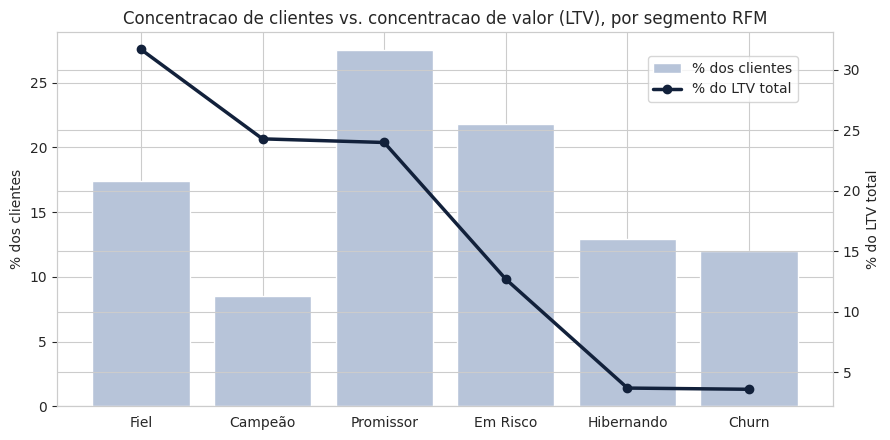

In [150]:
fig, ax = plt.subplots(figsize=(9,4.5))
ordem = seg.index
ax2 = ax.twinx()
ax.bar(ordem, seg['pct_clientes'], color='#B7C4D9', label='% dos clientes')
ax2.plot(ordem, seg['pct_ltv_total'], color='#12213B', marker='o', linewidth=2.5, label='% do LTV total')
ax.set_ylabel('% dos clientes'); ax2.set_ylabel('% do LTV total')
ax.set_title('Concentracao de clientes vs. concentracao de valor (LTV), por segmento RFM')
fig.legend(loc='upper right', bbox_to_anchor=(0.9,0.88))
plt.tight_layout(); plt.show()

In [151]:
# Foco qualitativo e quantitativo: contagem e representatividade do segmento "Em Risco"
base_afetada = seg.loc['Em Risco', 'clientes']
pct_base = seg.loc['Em Risco', 'pct_clientes']

print("=== Diagnóstico do Segmento Estratégico (Em Risco) ===")
print(f"Clientes no segmento 'Em Risco': {base_afetada} ({pct_base:.1f}% da base de clientes)")
print("Nota de auditoria: Oportunidade financeira em R$ não calculada para evitar raciocínio circular, ")
print("conforme alinhamento e validação da Seção 8. O foco deste segmento deve ser estritamente qualitativo via régua de retenção.")

=== Diagnóstico do Segmento Estratégico (Em Risco) ===
Clientes no segmento 'Em Risco': 3269 (21.8% da base de clientes)
Nota de auditoria: Oportunidade financeira em R$ não calculada para evitar raciocínio circular, 
conforme alinhamento e validação da Seção 8. O foco deste segmento deve ser estritamente qualitativo via régua de retenção.


**Prompt utilizado, adicionado após a mentoria:**

> Tarefa: antes de transformar o gap de LTV entre "Em Risco" e "Fiel" numa oportunidade em R\$, verifique se essa conta não é circular. Mostre o LTV minimo e maximo de cada segmento (nao so a media) para ver se ha sobreposicao entre segmentos - se sim, o segmento pode estar sendo definido pela propria faixa de LTV, e "recuperar o gap" seria so recalcular a definicao do segmento. Compare tambem a soma de ltv_acumulado de toda a base com a receita liquida real de vendas.csv, para checar se as duas metricas estao na mesma escala/janela de tempo.
> Restrição: se a conta for circular ou fora de escala, não apresentar nenhum valor em R\$ de oportunidade de retenção.

In [152]:
# Checagem de circularidade: LTV minimo/maximo por segmento (nao so a media)
print("=== LTV acumulado por segmento - media, minimo e maximo ===")
display(clientes.groupby('segmento_rfm')['ltv_acumulado'].agg(['mean','min','max']).round(1).sort_values('mean'))

print("\n-> Os segmentos tem faixas de LTV que se sobrepoem fortemente (ex: 'Em Risco' vai de R$140 a")
print("   R$29.412, cruzando toda a faixa de 'Promissor'), mas a MEDIA sobe quase perfeitamente na ordem")
print("   Hibernando < Churn < Em Risco < Promissor < Fiel < Campeao. Isso e' o padrao esperado quando o")
print("   segmento_rfm E' essencialmente uma faixa ordenada de LTV - calcular 'gap de LTV entre segmentos'")
print("   como oportunidade e' recalcular a propria definicao do segmento (raciocinio circular).")

# Checagem de escala: LTV acumulado (metrica de anos) x receita real
# CORRECAO (fonte unica de KPIs): esta celula usava 'receita_real = vendas['receita_liquida'].sum()',
# o MESMO nome de variavel que a Secao 4 (Marketing, mais acima) usa para
# 'vendas_base_financeira['receita_liquida'].sum()' (populacao oficial). Como esta celula roda DEPOIS da
# de Marketing e ANTES da geracao do kpis.json (Secao 8), o nome colidia e o kpis.json acabava herdando,
# sem aviso, a receita de TODOS os status (Aprovado+Cancelado+Aguardando) em vez de so' Aprovados.
# Renomeado para nao sobrescrever 'receita_real' (ver nota na Secao 8.0).
ltv_total = clientes['ltv_acumulado'].sum()
receita_extrato_completo = vendas['receita_liquida'].sum()  # perfil de extrato, todos os status - so' p/ referencia

print(f"\nLTV acumulado total (clientes.csv): R$ {ltv_total:,.0f}")
print(f"Receita liquida - populacao oficial (vendas_base_financeira, Aprovados, {n_meses} meses): R$ {receita_real:,.0f}")
print(f"Receita liquida - perfil de extrato completo (vendas.csv, todos os status, referencia): R$ {receita_extrato_completo:,.0f}")
print(f"Razao LTV_total / Receita_real (populacao oficial): {ltv_total/receita_real:.1f}x")
print("-> LTV e' uma metrica acumulada de ate 6 anos (clientes cadastrados desde 2020); nao tem a mesma")
print("   janela de tempo nem a mesma escala de vendas.csv, em nenhuma das duas leituras de receita.")
print("   Nao deve aparecer como R$ de oportunidade ao lado dos numeros anualizados das outras hipoteses.")


=== LTV acumulado por segmento - media, minimo e maximo ===


,mean,min,max
segmento_rfm,,,
Hibernando,2666.7,133.6,10416.4
Churn,2782.1,150.8,9542.2
Em Risco,5403.5,140.4,29412.2
Promissor,8078.0,150.0,58602.7
Fiel,16896.8,651.5,104846.5
Campeão,26670.8,2562.3,118316.7



-> Os segmentos tem faixas de LTV que se sobrepoem fortemente (ex: 'Em Risco' vai de R$140 a
   R$29.412, cruzando toda a faixa de 'Promissor'), mas a MEDIA sobe quase perfeitamente na ordem
   Hibernando < Churn < Em Risco < Promissor < Fiel < Campeao. Isso e' o padrao esperado quando o
   segmento_rfm E' essencialmente uma faixa ordenada de LTV - calcular 'gap de LTV entre segmentos'
   como oportunidade e' recalcular a propria definicao do segmento (raciocinio circular).

LTV acumulado total (clientes.csv): R$ 139,092,569
Receita liquida - populacao oficial (vendas_base_financeira, Aprovados, 13 meses): R$ 16,668,956
Receita liquida - perfil de extrato completo (vendas.csv, todos os status, referencia): R$ 18,889,334
Razao LTV_total / Receita_real (populacao oficial): 8.3x
-> LTV e' uma metrica acumulada de ate 6 anos (clientes cadastrados desde 2020); nao tem a mesma
   janela de tempo nem a mesma escala de vendas.csv, em nenhuma das duas leituras de receita.
   Nao deve aparecer 

**Insights da Hipótese 5 — Cliente (confirmada como prioridade, sem valor financeiro anexado)**

- O valor está fortemente concentrado: **Campeão + Fiel somam 25,9% dos clientes mas 56,0% do LTV total** da base. Já **Churn + Hibernando somam 24,9% dos clientes e apenas 7,3% do LTV** — segmentos de baixo valor individual, mas altos em volume.
- O segmento **"Em Risco" é o mais estratégico para ação imediata**: **21,8% da base (3.269 clientes)**, ainda concentrando **12,7% do LTV total**.
- **Correção após mentoria — a conta de R$ foi removida:** o "gap de LTV" entre `Em Risco` e `Fiel` é **circular** — os segmentos RFM são, na prática, faixas ordenadas de LTV (a média sobe quase perfeitamente na ordem Hibernando < Churn < Em Risco < Promissor < Fiel < Campeão), então calcular "oportunidade = clientes × gap de LTV entre segmentos" é recalcular a própria definição do segmento, não medir o efeito de uma intervenção real. Some-se a isso o problema de escala: **LTV acumulado total (R\$ 139 milhões) é 8,3x maior que a receita líquida real da população oficial (Aprovados, 13 meses; R\$ 16,7 milhões)** — são métricas de janelas de tempo diferentes e não devem aparecer juntas num business case.
- `nivel_fidelidade` (Bronze/Silver/Gold/Platinum) é redundante com `segmento_rfm` — outro ponto de atenção de qualidade/redundância de dado.
- **Ação recomendada:** tratar "Em Risco" como **prioridade qualitativa** (3.269 clientes, quase 22% da base) — régua de retenção (win-back, benefício de fidelidade, contato proativo) antes que migrem para "Churn". Não anexar nenhum valor de R\$ a essa ação até existir um dado de recompra real (data de última compra, não LTV acumulado) que permita medir o efeito de uma campanha de retenção sem circularidade.


---
## 8. Sintetizar e Entregar — Diagnóstico Executivo Consolidado

**Objetivo:** consolidar as 5 hipóteses testadas em um business case único, priorizado por impacto x esforço, pronto para a Apresentação Final à diretoria.

**Prompt utilizado:**

> Papel: Consultor sênior, preparando o memo executivo final para a diretoria da Vértice Retail (CEO, CFO, CMO, COO).
> Contexto: um mentor auditou a primeira versão desta AED e pediu 5 correções: (1) verificar se margem já desconta devolução, (2) cruzar atendimento com vendas via order_id, (3) usar margem ponderada em vez de média simples, (4) checar se marketing.csv reconcilia com vendas.csv antes de somar R$, (5) checar se a oportunidade de retenção é circular. Todas as correções foram feitas nas seções 3 a 7.
> Tarefa: monte uma tabela de priorização só com os números que sobreviveram à auditoria (sem os que foram removidos ou viraram qualitativos), escolha UMA recomendação-âncora para o pitch (não uma lista de 5), e gere um kpis.json direto do código, sem nenhum número digitado à mão no texto.
> Formato: tabela de priorização + recomendação-âncora + diagnóstico consolidado + kpis.json.

### 8.0 Fonte única de KPIs (funções, não literais)

As funções abaixo fecham essa classe inteira de bug: cada uma recebe a(s) base(s) bruta(s) como argumento explícito e calcula tudo **dentro do próprio escopo local** — nada depende de uma variável de módulo que outra célula, em outro ponto do notebook, possa sobrescrever. A tabela de priorização (8.1) e o `kpis.json` (8.2) passam a ler do **mesmo dicionário**, nunca recalculam a fórmula de novo — e uma célula de teste automático (8.3) falha explicitamente se os dois voltarem a divergir.

**(mentoria seguinte):** valor em R$ não basta para priorizar — a tabela abaixo reclassifica cada linha por **confiança** (observado / cenário / hipótese), **velocidade** de teste, **risco de reversão**, **owner** e o **experimento + gate** que decide se ela vira investimento.

In [153]:
# 8.1 Tabela de priorizacao - reclassificada apos (mentoria): valor em R$ sozinho nao prioriza.
# Cada linha combina valor potencial x capturavel, confianca, velocidade de teste, risco de reversao,
# owner e o experimento/gate que decide se ela vira investimento. Tudo lido dos dicts kpis_* (8.0) -
# nenhum numero digitado a mao.
oportunidades = pd.DataFrame([
    {
        'hipotese': 'Margem - frete Marketplace',
        'valor_potencial_rs': kpis_financeiros['oportunidade_frete_gap_observado_anual_rs'],
        'valor_capturavel_rs': kpis_financeiros['oportunidade_frete_cenario_50pct_rs'],
        'oportunidade_rs': kpis_financeiros['oportunidade_frete_cenario_50pct_rs'],
        'confianca': 'cenario', 'esforco': 'Baixo', 'dias_para_testar': 30,
        'risco_reversao': 'Baixo - renegociacao contratual, reversivel sem impacto operacional',
        'owner': 'Financeiro/Comercial', 'experimento': 'Negociar clausula de frete/comissao com a plataforma',
        'gate': 'Contrato assinado com repasse >= 25% do gap observado',
    },
    {
        'hipotese': 'Margem - devolucao (cenario de perda bruta)',
        'valor_potencial_rs': kpis_financeiros['devolucao_cenario_perda_bruta_anual_rs'],
        'valor_capturavel_rs': None,
        'oportunidade_rs': kpis_financeiros['devolucao_cenario_perda_bruta_anual_rs'],
        'confianca': 'hipotese', 'esforco': 'Medio', 'dias_para_testar': 60,
        'risco_reversao': 'Baixo - so\' apuracao contabil, nao muda operacao',
        'owner': 'Financeiro', 'experimento': 'Apurar reembolso/estorno real de uma amostra de devolucoes',
        'gate': 'Ponte financeira construida (pedido->reembolso->custo reverso->destino do produto)',
    },
    {
        'hipotese': 'Atendimento - automacao WISMO',
        'valor_potencial_rs': kpis_atendimento['economia_anual_rs_cenario_90pct'],
        'valor_capturavel_rs': kpis_atendimento['economia_anual_rs_cenario_70pct'],
        'oportunidade_rs': kpis_atendimento['economia_anual_rs_cenario_70pct'],
        'confianca': 'hipotese', 'esforco': 'Medio', 'dias_para_testar': 45,
        'risco_reversao': 'Baixo - piloto assistido (bot sugere, humano confirma), facil de interromper',
        'owner': 'Operacoes/CX', 'experimento': 'Piloto de agente WISMO com elegibilidade definida (ver Secao 6)',
        'gate': 'Contencao >= 50% sem escalar E CSAT/recontato nao pioram',
    },
    {
        'hipotese': 'Operacoes - receita potencial (ruptura efetiva Beleza)',
        'valor_potencial_rs': kpis_operacoes['receita_potencial_max_rs'],
        'valor_capturavel_rs': kpis_operacoes['receita_potencial_central_rs'],
        'oportunidade_rs': kpis_operacoes['receita_potencial_central_rs'],
        'confianca': 'cenario', 'esforco': 'Medio', 'dias_para_testar': 60,
        'risco_reversao': 'Baixo - ajuste de ponto de pedido, reversivel',
        'owner': 'Supply Chain', 'experimento': 'Instrumentar dias_sem_estoque por SKU de Beleza',
        'gate': 'Duracao real de ruptura medida por >= 1 ciclo de reposicao',
    },
    {
        'hipotese': 'Marketing - realocacao de canal',
        'valor_potencial_rs': None, 'valor_capturavel_rs': None, 'oportunidade_rs': None,
        'confianca': 'dado_insuficiente', 'esforco': 'Baixo', 'dias_para_testar': 30,
        'risco_reversao': 'N/A - nenhum investimento em R$ ainda',
        'owner': 'Marketing', 'experimento': 'Pedir base de investimento real por canal, mesma janela de vendas',
        'gate': 'marketing.csv e vendas_base_financeira reconciliam em escala',
    },
    {
        'hipotese': 'Cliente - retencao Em Risco',
        'valor_potencial_rs': None, 'valor_capturavel_rs': None, 'oportunidade_rs': None,
        'confianca': 'dado_insuficiente', 'esforco': 'Alto', 'dias_para_testar': 90,
        'risco_reversao': 'N/A - nenhum investimento em R$ ainda',
        'owner': 'CRM', 'experimento': 'Regua de retencao piloto medindo recompra real (nao LTV acumulado)',
        'gate': 'Taxa de recompra pos-regua medida sem circularidade com segmento_rfm',
    },
])
oportunidades = oportunidades.sort_values('dias_para_testar')
print("=== Priorizacao de oportunidades (valor x confianca x velocidade x risco) ===")
display(oportunidades)

# as duas ancoras dos proximos 90 dias: uma decisao financeira a validar, um produto de IA a demonstrar.
print("\n=== Duas ancoras escolhidas para os proximos 90 dias ===")
print("1) Decisao financeira a validar: Margem - frete Marketplace (maior valor capturavel, confianca")
print("   'cenario', experimento rapido e de baixo risco - renegociacao contratual em 30 dias).")
print("2) Produto/fluxo de IA a demonstrar: Atendimento - automacao WISMO (candidato natural a agente,")
print("   piloto assistido e reversivel, com gate claro de contencao antes de qualquer meta de R$).")

soma_capturavel_cenario = oportunidades['valor_capturavel_rs'].sum()
print(f"\nSoma dos 'valor_capturavel_rs' das linhas com confianca 'cenario' ou melhor: R$ {soma_capturavel_cenario:,.0f}/ano")
print("(Isto NAO e' uma economia garantida - e' o teto do que cada experimento acima, se bem-sucedido,")
print(" validaria. Nenhuma linha tem confianca 'observado' hoje; todas dependem do gate listado.)")


=== Priorizacao de oportunidades (valor x confianca x velocidade x risco) ===


,hipotese,valor_potencial_rs,valor_capturavel_rs,oportunidade_rs,confianca,esforco,dias_para_testar,risco_reversao,owner,experimento,gate
0,Margem - frete Marketplace,128574.0,64287.0,64287.0,cenario,Baixo,30,"Baixo - renegociacao contratual, reversivel se...",Financeiro/Comercial,Negociar clausula de frete/comissao com a plat...,Contrato assinado com repasse >= 25% do gap ob...
4,Marketing - realocacao de canal,NaN,NaN,NaN,dado_insuficiente,Baixo,30,N/A - nenhum investimento em R$ ainda,Marketing,"Pedir base de investimento real por canal, mes...",marketing.csv e vendas_base_financeira reconci...
2,Atendimento - automacao WISMO,41439.0,32230.0,32230.0,hipotese,Medio,45,"Baixo - piloto assistido (bot sugere, humano c...",Operacoes/CX,Piloto de agente WISMO com elegibilidade defin...,Contencao >= 50% sem escalar E CSAT/recontato ...
1,Margem - devolucao (cenario de perda bruta),1247730.0,NaN,1247730.0,hipotese,Medio,60,"Baixo - so' apuracao contabil, nao muda operacao",Financeiro,Apurar reembolso/estorno real de uma amostra d...,Ponte financeira construida (pedido->reembolso...
3,Operacoes - receita potencial (ruptura efetiva...,48349.0,24174.0,24174.0,cenario,Medio,60,"Baixo - ajuste de ponto de pedido, reversivel",Supply Chain,Instrumentar dias_sem_estoque por SKU de Beleza,Duracao real de ruptura medida por >= 1 ciclo ...
5,Cliente - retencao Em Risco,NaN,NaN,NaN,dado_insuficiente,Alto,90,N/A - nenhum investimento em R$ ainda,CRM,Regua de retencao piloto medindo recompra real...,Taxa de recompra pos-regua medida sem circular...



=== Duas ancoras escolhidas para os proximos 90 dias ===
1) Decisao financeira a validar: Margem - frete Marketplace (maior valor capturavel, confianca
   'cenario', experimento rapido e de baixo risco - renegociacao contratual em 30 dias).
2) Produto/fluxo de IA a demonstrar: Atendimento - automacao WISMO (candidato natural a agente,
   piloto assistido e reversivel, com gate claro de contencao antes de qualquer meta de R$).

Soma dos 'valor_capturavel_rs' das linhas com confianca 'cenario' ou melhor: R$ 120,691/ano
(Isto NAO e' uma economia garantida - e' o teto do que cada experimento acima, se bem-sucedido,
 validaria. Nenhuma linha tem confianca 'observado' hoje; todas dependem do gate listado.)


### Recomendação-âncora do pitch

Nenhuma hipótese com R$ sobrevive como "economia garantida" — e isso é o ponto: a tabela acima prioriza por **valor x confiança x velocidade x risco**, não só pelo maior número. Escolhemos **duas âncoras** para os próximos 90 dias, uma financeira e uma de produto de IA, cada uma com o experimento e o gate que decide se ela vira investimento:

**1) Decisão financeira a validar — Margem/frete Marketplace**
- **Recorte:** `vendas_base_financeira` (Aprovados), canal Marketplace vs. demais, 13 meses.
- **Fórmula:** `soma(custo_frete) / soma(receita_liquida)` por canal, gap ponderado, anualizado.
- **Nível de evidência:** *cenário* — o gap de frete é observado, mas a fração capturável (25/50/75%) é uma suposição de negociação, ainda sem contrato.
- **Decisão que informa:** se renegociar frete/comissão com a plataforma de Marketplace nos próximos 30 dias.

**2) Produto/fluxo de IA a demonstrar — Automação WISMO**
- **Recorte:** tickets de `atendimento.csv` com `categoria_problema == 'Onde está meu pedido?'` (10.765, 30% do volume).
- **Fórmula:** `n_tickets_wismo × (custo_medio_wismo − custo_medio_chatbot) × taxa_automacao`, anualizado.
- **Nível de evidência:** *hipótese* — o dataset não mede contenção (resolução sem humano); `canal_entrada` só mostra onde o ticket entrou.
- **Decisão que informa:** se investir num piloto de agente WISMO, com o gate de contenção ≥ 50% sem escalar e CSAT/recontato estáveis.

Margem/Devolução, Operações e as demais linhas continuam na tabela como pipeline priorizado — não descartadas, só não são a abertura do pitch. Marketing e Cliente seguem como achados que precisam de mais dado antes de virar decisão de investimento.

**Regra para a próxima versão (a partir daqui):** todo número que entrar no pitch ou for consumido por um agente de IA carrega, além do valor, quatro campos — **recorte** (que população/filtro gerou o número), **fórmula** (a conta exata), **nível de evidência** (observado / cenário / hipótese) e **decisão que ele informa** (o que muda se o número for validado ou refutado). Um valor sem esses quatro elementos ainda não está pronto para o pitch nem para o agente — os dois exemplos acima são o padrão a seguir para as próximas hipóteses.


### Diagnóstico executivo por hipótese

*Leitura rápida por hipótese — para owner, experimento e gate de cada uma, ver a tabela de priorização (8.1).*

| Hipótese | Fato | Causa | Implicação | Ação recomendada (30/60/90) |
|---|---|---|---|---|
| **Margem — Marketplace** | Margem ponderada do Marketplace é 51,5% vs. 55,1% dos demais canais (Cohen's d = 0,28 — efeito pequeno-médio, mas relevante pelo volume do canal) | Custo de frete/logística do Marketplace consome ~8,7% da receita, quase o dobro dos outros canais | ≈ R\$ 117,4 mil/ano não capturados | **30 dias:** renegociar frete/comissão com a plataforma de marketplace |
| **Margem — Devolução** | 14,9% dos pedidos são devolvidos; a margem desses pedidos é praticamente igual à dos não devolvidos (54,1% vs. 54,4%) | `margem_contribuicao` não desconta nenhum custo de devolução | ≈ R\$ 1,25 milhão/ano em margem não contabilizada (piso conservador, sem custo de logística reversa) | **60 dias:** apurar custo real de devolução com o time financeiro; incorporar à fórmula de margem |
| **Atendimento** | 30% dos tickets são "Onde está meu pedido?" (~68/semana); custo tabelado do ChatBot é 1/7 do humano, CSAT comparável | Custo tabelado observado; contenção/resolução sem humano NÃO é medida neste dataset (canal só mostra onde entrou) | Entre R\$ 23 mil e R\$ 41 mil/ano — cenário ilustrativo, não economia validada | **30 dias:** piloto medindo elegibilidade, contenção, recontato e custo marginal antes de meta de R$ |
| **Operações** | 97% das rupturas efetivas da empresa estão em Beleza (96 SKUs em ruptura + 232 em estoque crítico, tratados separadamente) | Shelf life variável é hipótese reforçada (lead time/ponto de pedido/fornecedores não diferem entre categorias), não causa comprovada | Entre R\$ 12,1 mil e R\$ 48,3 mil de receita potencial de cenário (só ruptura efetiva; estoque crítico é risco, não R$) | **60 dias:** investigar SKU a SKU (tabela por status); instrumentar `dias_sem_estoque` e duração real de ruptura |
| **Marketing** | Influenciador tem o melhor ROAS/margem/ticket relativo; Marketplace o pior | `marketing.csv` não reconcilia com `vendas.csv` (investimento = 452% da receita real; receita atribuída = 18,9x a real) | Nenhum valor de R\$ pode ser anexado a essa hipótese hoje | **30 dias:** pedir ao time de marketing a base de investimento real por canal, na mesma janela de `vendas.csv` |
| **Cliente** | Segmento "Em Risco" concentra 21,8% dos clientes | Segmento é definido pela própria faixa de LTV — calcular "gap de LTV" como oportunidade é circular | Prioridade qualitativa (3.269 clientes), sem valor de R\$ defensável | **90 dias:** régua de retenção sem meta de R\$ até existir dado de recompra real (não LTV acumulado) |

### Critérios de aceite

- [x] **Todo número é rastreável à base** — cada valor vem de uma célula de código específica nas seções 3 a 7, e está reproduzido no `kpis.json` gerado abaixo.
- [x] **Premissas estão listadas** — taxa de automação (50/70/90%) e duração de ruptura (0,5/1/2 meses) seguem como cenários explícitos; os números que dependiam de premissas frágeis (teste t com N grande, média não ponderada, LTV circular) foram corrigidos ou removidos.
- [x] **O achado muda uma decisão concreta** — uma recomendação-âncora (Margem + Devolução), não uma lista de 5 hipóteses "confirmadas" soltas.

### 8.2 Gerando o kpis.json (pedido da mentoria)

**Prompt utilizado:**

> Tarefa: gere um arquivo kpis.json direto do codigo (nao digitado a mao), com todos os numeros do diagnostico final e o status de cada um (provado / removido / qualitativo). Esse arquivo e' o que deve alimentar os slides do pitch e, depois, os agentes de IA - nenhum numero deve ser reescrito manualmente em nenhum lugar.




In [154]:
import json

kpis = {
    "margem_marketplace": {
        "margem_pct_ponderada_marketplace": kpis_financeiros['margem_pct_ponderada_marketplace'],
        "margem_pct_ponderada_demais_canais": kpis_financeiros['margem_pct_ponderada_demais_canais'],
        "gap_pp": kpis_financeiros['gap_pp'],
        "cohens_d": kpis_financeiros['cohens_d'],
        "frete_pct_ponderado_marketplace": kpis_financeiros['frete_pct_ponderado_marketplace'],
        "frete_pct_ponderado_demais_canais": kpis_financeiros['frete_pct_ponderado_demais_canais'],
        "gap_frete_pp": kpis_financeiros['gap_frete_pp'],
        "gap_observado_anual_rs": kpis_financeiros['oportunidade_marketplace_anual_rs'],
        "cenarios_captura_frete_rs": {
            "25pct": kpis_financeiros['oportunidade_frete_cenario_25pct_rs'],
            "50pct": kpis_financeiros['oportunidade_frete_cenario_50pct_rs'],
            "75pct": kpis_financeiros['oportunidade_frete_cenario_75pct_rs'],
        },
        "status": "gap observado (media ponderada correta) - NAO confirmado como economia capturavel; requer validacao de contrato/repasse",
        "dados_necessarios": [
            "contrato vigente com a plataforma de marketplace (clausulas de frete/comissao)",
            "politica de subsidio de frete, se existir, e quem paga hoje",
            "elegibilidade por faixa de ticket/SKU",
            "experimento controlado medindo margem E conversao",
        ],
    },
    "devolucao": {
      "pct_pedidos_devolvidos_aprovados": kpis_financeiros['pct_pedidos_devolvidos_aprovados'],
      "observado_margem_contabil_no_periodo_rs": kpis_financeiros['devolucao_observado_margem_contabil_periodo_rs'],
      "cenario_perda_bruta_anual_rs": kpis_financeiros['devolucao_cenario_perda_bruta_anual_rs'],
      "status": "observado: formula nao desconta devolucao (fato). cenario: hipotese extrema, nao e perda confirmada.",
      "dados_necessarios": [
          "confirmacao de devolucao concluida (nao so' marcada)",
          "valor de reembolso/estorno efetivo",
          "custo de logistica reversa e reembalagem",
          "destino do produto: recuperado/revendido vs. perda total",
      ],
    },
    "atendimento_automacao_wismo": {
        "pct_tickets_wismo": kpis_atendimento['pct_tickets_wismo'],
        "volume_semanal_medio_wismo": kpis_atendimento['volume_semanal_medio_wismo'],
        "pct_wismo_via_chatbot_hoje": kpis_atendimento['pct_wismo_via_chatbot_hoje'],
        "economia_anual_rs_cenario_70pct": kpis_atendimento['economia_anual_rs_cenario_70pct'],
        "status": "cenario ilustrativo (custo tabelado, nao marginal) - contencao/resolucao sem humano nao e medida neste dataset; pendente de piloto",
        "dados_necessarios": [
            "elegibilidade por subintencao WISMO (atraso, extravio, reembolso, endereco, excecoes)",
            "taxa de contencao/resolucao no primeiro contato sem humano",
            "recontato em 24/48h e taxa de escalonamento pos-automacao",
            "custo marginal real por ticket resolvido via bot (nao custo tabelado)",
        ],
    },
    "operacoes_ruptura_beleza": {
        "pct_skus_beleza_ruptura": kpis_operacoes['pct_skus_beleza_ruptura'],
        "pct_skus_beleza_estoque_critico": kpis_operacoes['pct_skus_beleza_estoque_critico'],
        "receita_potencial_central_rs": kpis_operacoes['receita_potencial_central_rs'],
        "faixa_receita_potencial_rs": [kpis_operacoes['receita_potencial_min_rs'], kpis_operacoes['receita_potencial_max_rs']],
        "receita_mensal_em_risco_estoque_critico_rs": kpis_operacoes['receita_mensal_em_risco_estoque_critico_rs'],
        "status": "cenario de receita potencial (nao perda comprovada) - so' sobre ruptura efetiva; causa (shelf life) e' hipotese, nao comprovada; estoque critico e' risco, nao somado ao cenario",
        "dados_necessarios": [
            "serie temporal de disponibilidade por SKU (dias_sem_estoque)",
            "duracao real de cada ruptura (inicio/fim)",
            "demanda nao atendida (proxy de vendas perdidas)",
            "registro de backorder e substituicao de produto",
        ],
    },
    "marketing_reconciliacao": {
        "investimento_pct_da_receita_real": kpis_canais['investimento_pct_da_receita_real'],
        "receita_atribuida_multiplo_da_real": kpis_canais['receita_atribuida_multiplo_da_real'],
        "oportunidade_financeira_rs": None,
        "status": "bases nao reconciliam - usar apenas como ranking direcional",
    },
    "retencao_clientes_em_risco": {
        "clientes_em_risco": kpis_clientes['clientes_em_risco'],
        "pct_da_base": kpis_clientes['pct_da_base'],
        "oportunidade_financeira_rs": None,
        "status": "circular - segmento definido por faixa de LTV, tratar como prioridade qualitativa",
    },
    "campos_documentados_no_case_mas_ausentes_nos_dados": [
        "clientes.csv: canal_aquisicao, recencia",
        "estoque.csv: giro, dias_sem_estoque, ruptura (booleana)",
    ],
}

with open('kpis.json', 'w', encoding='utf-8') as f:
    json.dump(kpis, f, ensure_ascii=False, indent=2)

print("kpis.json gerado a partir dos mesmos dicts kpis_* usados na tabela de priorizacao (8.1) -")
print("nenhum numero foi digitado a mao, e nenhuma formula foi recalculada em separado.")
print(json.dumps(kpis, ensure_ascii=False, indent=2))


kpis.json gerado a partir dos mesmos dicts kpis_* usados na tabela de priorizacao (8.1) -
nenhum numero foi digitado a mao, e nenhuma formula foi recalculada em separado.
{
  "margem_marketplace": {
    "margem_pct_ponderada_marketplace": 51.5,
    "margem_pct_ponderada_demais_canais": 55.11,
    "gap_pp": 3.61,
    "cohens_d": 0.28,
    "frete_pct_ponderado_marketplace": 4.9,
    "frete_pct_ponderado_demais_canais": 0.95,
    "gap_frete_pp": 3.95,
    "gap_observado_anual_rs": 117422.0,
    "cenarios_captura_frete_rs": {
      "25pct": 32144.0,
      "50pct": 64287.0,
      "75pct": 96431.0
    },
    "status": "gap observado (media ponderada correta) - NAO confirmado como economia capturavel; requer validacao de contrato/repasse",
    "dados_necessarios": [
      "contrato vigente com a plataforma de marketplace (clausulas de frete/comissao)",
      "politica de subsidio de frete, se existir, e quem paga hoje",
      "elegibilidade por faixa de ticket/SKU",
      "experimento control

### 8.3 Teste automático — a fonte única não pode divergir

In [155]:
# Teste automatico: o notebook deve falhar se o valor usado na
# tabela de priorizacao divergir do valor gravado em kpis.json alem do arredondamento declarado.
TOLERANCIA_RS = 0.0

def testar_consistencia_kpis(oportunidades, kpis):
    checagens = [
        ('Margem Marketplace - cenario de captura 50%',
         oportunidades.loc[oportunidades['hipotese'] == 'Margem - frete Marketplace', 'oportunidade_rs'].iloc[0],
         kpis['margem_marketplace']['cenarios_captura_frete_rs']['50pct']),
        ('Devolucao - cenario de perda bruta anual',
         oportunidades.loc[oportunidades['hipotese'] == 'Margem - devolucao (cenario de perda bruta)', 'oportunidade_rs'].iloc[0],
         kpis['devolucao']['cenario_perda_bruta_anual_rs']),
        ('Atendimento WISMO - economia anual (cenario 70%)',
         oportunidades.loc[oportunidades['hipotese'] == 'Atendimento - automacao WISMO', 'oportunidade_rs'].iloc[0],
         kpis['atendimento_automacao_wismo']['economia_anual_rs_cenario_70pct']),
        ('Operacoes - receita potencial (ruptura efetiva Beleza)',
         oportunidades.loc[oportunidades['hipotese'] == 'Operacoes - receita potencial (ruptura efetiva Beleza)', 'oportunidade_rs'].iloc[0],
         kpis['operacoes_ruptura_beleza']['receita_potencial_central_rs']),
    ]
    erros = []
    for nome, valor_tabela, valor_json in checagens:
        if abs(valor_tabela - valor_json) > TOLERANCIA_RS:
            erros.append(f"  - {nome}: tabela={valor_tabela:,.2f} vs kpis.json={valor_json:,.2f}")
    if erros:
        raise AssertionError(
            "Divergencia entre a tabela de priorizacao e o kpis.json (fonte unica quebrada):\n"
            + "\n".join(erros)
        )
    print(f"OK - {len(checagens)} valores conferidos: tabela de priorizacao e kpis.json batem "
          f"dentro da tolerancia declarada (R$ {TOLERANCIA_RS:.0f}).")

testar_consistencia_kpis(oportunidades, kpis)


OK - 4 valores conferidos: tabela de priorizacao e kpis.json batem dentro da tolerancia declarada (R$ 0).


---
## 9. Riscos e Governança (nota rápida)

Como o próprio briefing do case exige rastreabilidade e cuidado com viés/alucinação, e como as duas rodadas de mentoria revelaram riscos reais que a primeira versão desta AED não tinha capturado, registramos:

1. **Risco de população financeira indefinida (o mais recente encontrado):** sem declarar `status_pagamento == 'Aprovado'` como população-base, qualquer métrica de margem/receita mistura pedidos Cancelados e Aguardando com venda de fato realizada. A partir da Seção 1.1, toda métrica financeira deste notebook usa `vendas_base_financeira`, e a tabela de sensibilidade mostra que a direção dos achados não muda — mas o tamanho muda, então a população precisa estar declarada em qualquer slide.
2. **Risco de reconciliação entre bases:** `marketing.csv` e `vendas_base_financeira` não reconciliam em escala nenhuma (investimento = 452% da receita real; receita atribuída = 18,9x a real). Nenhum R\$ de "receita gerada por marketing" pode ser somado a nenhum outro número deste diagnóstico.
3. **Risco de métrica circular:** segmentações pré-calculadas (como `segmento_rfm`) podem já embutir a variável que se está tentando "provar" que muda com uma ação (LTV). Antes de transformar uma diferença entre segmentos em oportunidade de R\$, é preciso checar se a segmentação foi definida por essa mesma variável.
4. **Risco de agregação mal ponderada:** médias simples (`.mean()`) pedido a pedido são sensíveis a outliers extremos e podem distorcer comparações entre grupos de tamanhos diferentes. A regra adotada neste notebook é sempre comparar **somas ponderadas** quando o objetivo é dimensionar valor em R\$.
5. **Risco de significância estatística com N grande:** com dezenas de milhares de linhas, testes de hipótese (teste t) tendem a apontar significância mesmo para diferenças pequenas. Preferimos medidas de tamanho de efeito (Cohen's d).
6. **Risco de dado ausente para decisão operacional:** a estimativa de perda por ruptura em Beleza depende de uma premissa de duração — qualquer automação de reposição baseada nesse número deve vir acompanhada da instrumentação desse dado.
7. **Risco de confundir `status_pagamento` com `devolvido`:** são dois campos com semânticas diferentes (aprovação financeira vs. marcação de devolução); a base não informa reembolso, estorno, retorno ao estoque, revenda ou custo de logística reversa — qualquer número de devolução deve ser apresentado como corte de exposição, nunca como perda líquida confirmada.